In [32]:
import os
from pathlib import Path

print("Current Working Directory:", os.getcwd())
print("Datasets exists?", Path("Datasets").exists())

Current Working Directory: /Users/ishita/Coder/Proj/Skincare-Recommendation
Datasets exists? True


In [33]:
import numpy as np
import pandas as pd

from pathlib import Path
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt

Loading the datasets 

In [34]:
DATA_DIR = Path("Datasets")

review_files = [
    DATA_DIR / "reviews_0-250.csv",
    DATA_DIR / "reviews_250-500.csv",
    DATA_DIR / "reviews_500-750.csv",
    DATA_DIR / "reviews_750-1250.csv",
    DATA_DIR / "reviews_1250-end.csv",
]

df_reviews = pd.concat([pd.read_csv(f) for f in review_files], ignore_index=True)
df_reviews = df_reviews.drop(columns=["Unnamed: 0"], errors="ignore")

print("Reviews shape:", df_reviews.shape)
df_reviews.head()

/var/folders/7w/vrg67xp53xq_j1lvk8w5th380000gn/T/ipykernel_65640/3914178347.py:11: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  df_reviews = pd.concat([pd.read_csv(f) for f in review_files], ignore_index=True)
/var/folders/7w/vrg67xp53xq_j1lvk8w5th380000gn/T/ipykernel_65640/3914178347.py:11: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  df_reviews = pd.concat([pd.read_csv(f) for f in review_files], ignore_index=True)
/var/folders/7w/vrg67xp53xq_j1lvk8w5th380000gn/T/ipykernel_65640/3914178347.py:11: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  df_reviews = pd.concat([pd.read_csv(f) for f in review_files], ignore_index=True)


Reviews shape: (1094411, 18)


,author_id,rating,is_recommended,helpfulness,total_feedback_count,total_neg_feedback_count,total_pos_feedback_count,submission_time,review_text,review_title,skin_tone,eye_color,skin_type,hair_color,product_id,product_name,brand_name,price_usd
0,1741593524,5,1.0,1.0,2,0,2,2023-02-01,I use this with the Nudestix “Citrus Clean Bal...,Taught me how to double cleanse!,NaN,brown,dry,black,P504322,Gentle Hydra-Gel Face Cleanser,NUDESTIX,19.0
1,31423088263,1,0.0,NaN,0,0,0,2023-03-21,I bought this lip mask after reading the revie...,Disappointed,NaN,NaN,NaN,NaN,P420652,Lip Sleeping Mask Intense Hydration with Vitam...,LANEIGE,24.0
2,5061282401,5,1.0,NaN,0,0,0,2023-03-21,My review title says it all! I get so excited ...,New Favorite Routine,light,brown,dry,blonde,P420652,Lip Sleeping Mask Intense Hydration with Vitam...,LANEIGE,24.0
3,6083038851,5,1.0,NaN,0,0,0,2023-03-20,I’ve always loved this formula for a long time...,Can't go wrong with any of them,NaN,brown,combination,black,P420652,Lip Sleeping Mask Intense Hydration with Vitam...,LANEIGE,24.0
4,47056667835,5,1.0,NaN,0,0,0,2023-03-20,"If you have dry cracked lips, this is a must h...",A must have !!!,light,hazel,combination,NaN,P420652,Lip Sleeping Mask Intense Hydration with Vitam...,LANEIGE,24.0


This contains product-level information such as category, brand, price, and ingredients.

In [35]:
df_products = pd.read_csv(DATA_DIR / "product_info.csv")

df_products = df_products.rename(
    columns={
        "rating": "avg_product_rating",
        "reviews": "num_reviews"
    }
)

print("Products shape:", df_products.shape)
df_products.head()

Products shape: (8494, 27)


,product_id,product_name,brand_id,brand_name,loves_count,avg_product_rating,num_reviews,size,variation_type,variation_value,...,online_only,out_of_stock,sephora_exclusive,highlights,primary_category,secondary_category,tertiary_category,child_count,child_max_price,child_min_price
0,P473671,Fragrance Discovery Set,6342,19-69,6320,3.6364,11.0,NaN,NaN,NaN,...,1,0,0,"['Unisex/ Genderless Scent', 'Warm &Spicy Scen...",Fragrance,Value & Gift Sets,Perfume Gift Sets,0,NaN,NaN
1,P473668,La Habana Eau de Parfum,6342,19-69,3827,4.1538,13.0,3.4 oz/ 100 mL,Size + Concentration + Formulation,3.4 oz/ 100 mL,...,1,0,0,"['Unisex/ Genderless Scent', 'Layerable Scent'...",Fragrance,Women,Perfume,2,85.0,30.0
2,P473662,Rainbow Bar Eau de Parfum,6342,19-69,3253,4.2500,16.0,3.4 oz/ 100 mL,Size + Concentration + Formulation,3.4 oz/ 100 mL,...,1,0,0,"['Unisex/ Genderless Scent', 'Layerable Scent'...",Fragrance,Women,Perfume,2,75.0,30.0
3,P473660,Kasbah Eau de Parfum,6342,19-69,3018,4.4762,21.0,3.4 oz/ 100 mL,Size + Concentration + Formulation,3.4 oz/ 100 mL,...,1,0,0,"['Unisex/ Genderless Scent', 'Layerable Scent'...",Fragrance,Women,Perfume,2,75.0,30.0
4,P473658,Purple Haze Eau de Parfum,6342,19-69,2691,3.2308,13.0,3.4 oz/ 100 mL,Size + Concentration + Formulation,3.4 oz/ 100 mL,...,1,0,0,"['Unisex/ Genderless Scent', 'Layerable Scent'...",Fragrance,Women,Perfume,2,75.0,30.0


We only want skincare recommendations, so we filter the product table to skincare.

In [36]:
df_products = df_products[df_products["primary_category"] == "Skincare"].copy()

print("Skincare products:", df_products.shape)
print(df_products["primary_category"].value_counts(dropna=False))

Skincare products: (2420, 27)
primary_category
Skincare    2420
Name: count, dtype: int64


#### Merge reviews with skincare product info: This keeps only the reviews that belong to skincare products and attaches product metadata.

In [37]:
product_cols = [
    "product_id", "product_name", "brand_name", "ingredients", "price_usd",
    "highlights", "primary_category", "secondary_category", "tertiary_category",
    "avg_product_rating", "num_reviews", "loves_count", "sale_price_usd", "value_price_usd"
]

df_merged = df_reviews.merge(
    df_products[product_cols],
    on="product_id",
    how="inner"
)

print("Merged skincare review data shape:", df_merged.shape)
df_merged.head()

Merged skincare review data shape: (1094411, 31)


,author_id,rating,is_recommended,helpfulness,total_feedback_count,total_neg_feedback_count,total_pos_feedback_count,submission_time,review_text,review_title,...,price_usd_y,highlights,primary_category,secondary_category,tertiary_category,avg_product_rating,num_reviews,loves_count,sale_price_usd,value_price_usd
0,1741593524,5,1.0,1.0,2,0,2,2023-02-01,I use this with the Nudestix “Citrus Clean Bal...,Taught me how to double cleanse!,...,19.0,['Clean at Sephora'],Skincare,Cleansers,NaN,5.0000,1.0,177,NaN,NaN
1,31423088263,1,0.0,NaN,0,0,0,2023-03-21,I bought this lip mask after reading the revie...,Disappointed,...,24.0,"['allure 2019 Best of Beauty Award Winner', 'C...",Skincare,Lip Balms & Treatments,NaN,4.3508,16118.0,1081315,NaN,NaN
2,5061282401,5,1.0,NaN,0,0,0,2023-03-21,My review title says it all! I get so excited ...,New Favorite Routine,...,24.0,"['allure 2019 Best of Beauty Award Winner', 'C...",Skincare,Lip Balms & Treatments,NaN,4.3508,16118.0,1081315,NaN,NaN
3,6083038851,5,1.0,NaN,0,0,0,2023-03-20,I’ve always loved this formula for a long time...,Can't go wrong with any of them,...,24.0,"['allure 2019 Best of Beauty Award Winner', 'C...",Skincare,Lip Balms & Treatments,NaN,4.3508,16118.0,1081315,NaN,NaN
4,47056667835,5,1.0,NaN,0,0,0,2023-03-20,"If you have dry cracked lips, this is a must h...",A must have !!!,...,24.0,"['allure 2019 Best of Beauty Award Winner', 'C...",Skincare,Lip Balms & Treatments,NaN,4.3508,16118.0,1081315,NaN,NaN


In [38]:
# Check merged dataframe columns carefully
print("df_merged shape:", df_merged.shape)
print("\nColumns in df_merged:")
print(df_merged.columns.tolist())

# Check columns with suffixes created during merge
suffix_cols = [col for col in df_merged.columns if col.endswith("_x") or col.endswith("_y")]
print("\nColumns with _x/_y suffixes:")
print(suffix_cols)

df_merged shape: (1094411, 31)

Columns in df_merged:
['author_id', 'rating', 'is_recommended', 'helpfulness', 'total_feedback_count', 'total_neg_feedback_count', 'total_pos_feedback_count', 'submission_time', 'review_text', 'review_title', 'skin_tone', 'eye_color', 'skin_type', 'hair_color', 'product_id', 'product_name_x', 'brand_name_x', 'price_usd_x', 'product_name_y', 'brand_name_y', 'ingredients', 'price_usd_y', 'highlights', 'primary_category', 'secondary_category', 'tertiary_category', 'avg_product_rating', 'num_reviews', 'loves_count', 'sale_price_usd', 'value_price_usd']

Columns with _x/_y suffixes:
['product_name_x', 'brand_name_x', 'price_usd_x', 'product_name_y', 'brand_name_y', 'price_usd_y']


In [39]:
# Make a clean merged dataframe for future modeling
df_merged_clean = df_merged.copy()

# Prefer product metadata columns from df_products where duplicate suffixes exist
rename_map = {}

for col in df_merged_clean.columns:
    if col.endswith("_y"):
        base_col = col[:-2]
        rename_map[col] = base_col

df_merged_clean = df_merged_clean.rename(columns=rename_map)

# Drop duplicate _x columns if matching clean column exists
drop_cols = []

for col in df_merged_clean.columns:
    if col.endswith("_x"):
        base_col = col[:-2]
        if base_col in df_merged_clean.columns:
            drop_cols.append(col)

df_merged_clean = df_merged_clean.drop(columns=drop_cols, errors="ignore")

print("Clean merged shape:", df_merged_clean.shape)
print("\nClean merged columns:")
print(df_merged_clean.columns.tolist())

Clean merged shape: (1094411, 28)

Clean merged columns:
['author_id', 'rating', 'is_recommended', 'helpfulness', 'total_feedback_count', 'total_neg_feedback_count', 'total_pos_feedback_count', 'submission_time', 'review_text', 'review_title', 'skin_tone', 'eye_color', 'skin_type', 'hair_color', 'product_id', 'product_name', 'brand_name', 'ingredients', 'price_usd', 'highlights', 'primary_category', 'secondary_category', 'tertiary_category', 'avg_product_rating', 'num_reviews', 'loves_count', 'sale_price_usd', 'value_price_usd']


In [40]:
df_merged = df_merged_clean.copy()

#### Keep only the columns needed for collaborative filtering

For the rating model, the core information is:

- user id
- product id
- rating

We keep metadata separately for later display and possible hybrid extensions.

In [41]:
df_interactions = df_merged[["author_id", "product_id", "rating"]].copy()
df_interactions = df_interactions.dropna(subset=["author_id", "product_id", "rating"])

print("Interaction rows before deduplication:", len(df_interactions))
df_interactions.head()

Interaction rows before deduplication: 1094411


,author_id,product_id,rating
0,1741593524,P504322,5
1,31423088263,P420652,1
2,5061282401,P420652,5
3,6083038851,P420652,5
4,47056667835,P420652,5


Sometimes the same user rated the same product more than once.
We collapse those duplicates into one average rating per user-product pair.

In [42]:
duplicate_pairs = df_interactions.duplicated(subset=["author_id", "product_id"]).sum()
print("Duplicate user-product pairs:", duplicate_pairs)

df_interactions = (
    df_interactions
    .groupby(["author_id", "product_id"], as_index=False)["rating"]
    .mean()
)

print("Interaction rows after deduplication:", len(df_interactions))
df_interactions.head()

Duplicate user-product pairs: 5520
Interaction rows after deduplication: 1088891


,author_id,product_id,rating
0,538863,P420652,1.0
1,549704,P218700,5.0
2,557770,P232903,5.0
3,561736,P421998,5.0
4,561736,P445951,5.0


### Filter to active users and products

This step reduces extreme sparsity.
We keep:
- users with at least 10 ratings
- products with at least 20 ratings

This makes collaborative filtering more stable.

In [43]:
MIN_USER_RATINGS = 10
MIN_PRODUCT_RATINGS = 20

user_counts = df_interactions["author_id"].value_counts()
product_counts = df_interactions["product_id"].value_counts()

active_users = user_counts[user_counts >= MIN_USER_RATINGS].index
active_products = product_counts[product_counts >= MIN_PRODUCT_RATINGS].index

df_cf = df_interactions[
    df_interactions["author_id"].isin(active_users) &
    df_interactions["product_id"].isin(active_products)
].copy()

print("Filtered interaction rows:", len(df_cf))
print("Filtered unique users:", df_cf["author_id"].nunique())
print("Filtered unique products:", df_cf["product_id"].nunique())

Filtered interaction rows: 133720
Filtered unique users: 7029
Filtered unique products: 1752


In [44]:
# Check data types
print(df_merged.dtypes)

# Convert important IDs to string
df_merged["author_id"] = df_merged["author_id"].astype(str)
df_merged["product_id"] = df_merged["product_id"].astype(str)

df_interactions["author_id"] = df_interactions["author_id"].astype(str)
df_interactions["product_id"] = df_interactions["product_id"].astype(str)

df_cf["author_id"] = df_cf["author_id"].astype(str)
df_cf["product_id"] = df_cf["product_id"].astype(str)

# Convert rating to numeric
df_merged["rating"] = pd.to_numeric(df_merged["rating"], errors="coerce")
df_interactions["rating"] = pd.to_numeric(df_interactions["rating"], errors="coerce")
df_cf["rating"] = pd.to_numeric(df_cf["rating"], errors="coerce")

# Convert submission_time to datetime if available
if "submission_time" in df_merged.columns:
    df_merged["submission_time"] = pd.to_datetime(df_merged["submission_time"], errors="coerce")

print("Data type cleanup complete.")

author_id                    object
rating                        int64
is_recommended              float64
helpfulness                 float64
total_feedback_count          int64
total_neg_feedback_count      int64
total_pos_feedback_count      int64
submission_time              object
review_text                  object
review_title                 object
skin_tone                    object
eye_color                    object
skin_type                    object
hair_color                   object
product_id                   object
product_name                 object
brand_name                   object
ingredients                  object
price_usd                   float64
highlights                   object
primary_category             object
secondary_category           object
tertiary_category            object
avg_product_rating          float64
num_reviews                 float64
loves_count                   int64
sale_price_usd              float64
value_price_usd             

In [45]:
def sparsity_summary(df, user_col="author_id", item_col="product_id", rating_col="rating", name="Data"):
    n_users = df[user_col].nunique()
    n_items = df[item_col].nunique()
    observed = len(df)
    total_possible = n_users * n_items
    missing = total_possible - observed
    missing_pct = 100 * missing / total_possible
    density_pct = 100 * observed / total_possible
    
    print(f" {name} ")
    print(f"Users: {n_users:,}")
    print(f"Products: {n_items:,}")
    print(f"Observed ratings: {observed:,}")
    print(f"Total possible user-product cells: {total_possible:,}")
    print(f"Missing cells: {missing:,}")
    print(f"Missing %: {missing_pct:.2f}%")
    print(f"Density %: {density_pct:.2f}%")
    print()

sparsity_summary(df_interactions, name="Before active-user/product filtering")
sparsity_summary(df_cf, name="After active-user/product filtering")

 Before active-user/product filtering 
Users: 503,216
Products: 2,351
Observed ratings: 1,088,891
Total possible user-product cells: 1,183,060,816
Missing cells: 1,181,971,925
Missing %: 99.91%
Density %: 0.09%

 After active-user/product filtering 
Users: 6,798
Products: 1,752
Observed ratings: 133,720
Total possible user-product cells: 11,910,096
Missing cells: 11,776,376
Missing %: 98.88%
Density %: 1.12%



In [46]:
print("Rating distribution after filtering:")
rating_dist_filtered = df_cf["rating"].value_counts().sort_index()
print(rating_dist_filtered)

print("\nRating distribution percentage after filtering:")
print((rating_dist_filtered / len(df_cf) * 100).round(2))

Rating distribution after filtering:
rating
1.000000     3440
1.500000        7
1.666667        1
2.000000     3952
2.500000        7
3.000000     7877
3.333333        2
3.500000       13
4.000000    23532
4.333333        1
4.500000       70
4.666667        3
4.750000        1
5.000000    94814
Name: count, dtype: int64

Rating distribution percentage after filtering:
rating
1.000000     2.57
1.500000     0.01
1.666667     0.00
2.000000     2.96
2.500000     0.01
3.000000     5.89
3.333333     0.00
3.500000     0.01
4.000000    17.60
4.333333     0.00
4.500000     0.05
4.666667     0.00
4.750000     0.00
5.000000    70.90
Name: count, dtype: float64


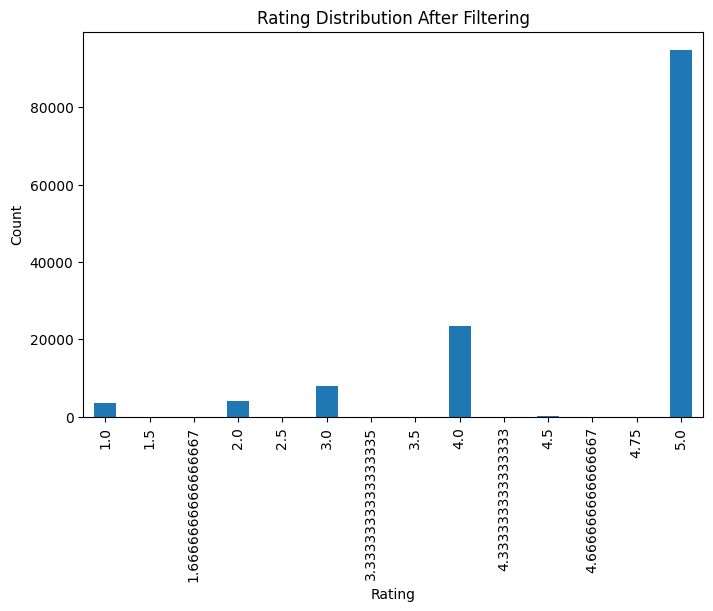

In [47]:
plt.figure(figsize=(8, 5))
df_cf["rating"].value_counts().sort_index().plot(kind="bar")
plt.title("Rating Distribution After Filtering")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

Ratings per user summary:
count    6798.000000
mean       19.670491
std        15.495446
min         6.000000
25%        11.000000
50%        14.000000
75%        21.000000
max       286.000000
Name: count, dtype: float64

Top 10 most active users:
author_id
1696370280     286
1288462295     199
7375781965     154
5060164185     150
2330399812     149
1930716686     149
1492711942     134
1738022745     134
10690040573    128
5836301803     114
Name: count, dtype: int64

Users with exactly 10 ratings:
1221


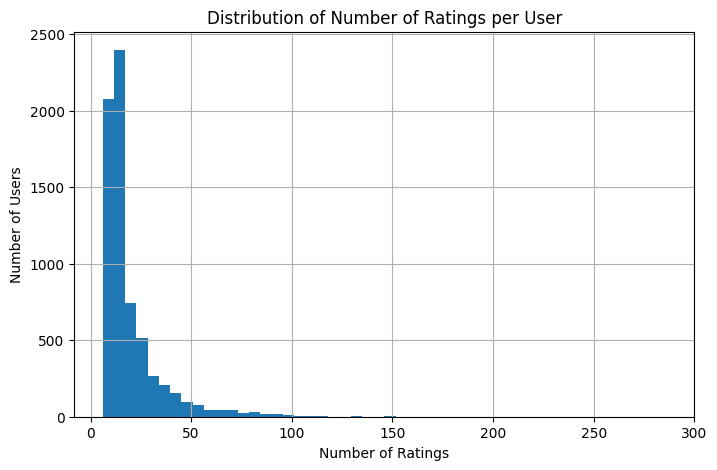

In [48]:
user_rating_counts = df_cf["author_id"].value_counts()

print("Ratings per user summary:")
print(user_rating_counts.describe())

print("\nTop 10 most active users:")
print(user_rating_counts.head(10))

print("\nUsers with exactly 10 ratings:")
print((user_rating_counts == 10).sum())

plt.figure(figsize=(8, 5))
user_rating_counts.hist(bins=50)
plt.title("Distribution of Number of Ratings per User")
plt.xlabel("Number of Ratings")
plt.ylabel("Number of Users")
plt.show()

Ratings per product summary:
count    1752.000000
mean       76.324201
std       131.462524
min         1.000000
25%         9.000000
50%        33.000000
75%        84.000000
max      1435.000000
Name: count, dtype: float64

Top 10 most rated products:
product_id
P443352    1435
P423688    1435
P500633    1324
P270594    1271
P309308    1050
P476414    1032
P503936     992
P442840     878
P479860     878
P479841     844
Name: count, dtype: int64

Products with exactly 20 ratings:
14


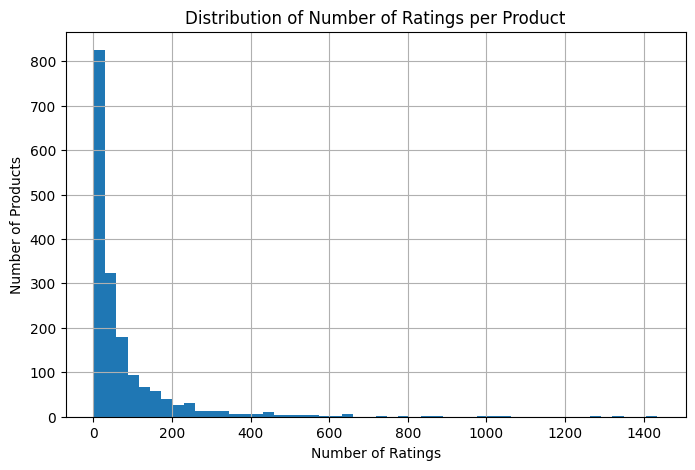

In [49]:
product_rating_counts = df_cf["product_id"].value_counts()

print("Ratings per product summary:")
print(product_rating_counts.describe())

print("\nTop 10 most rated products:")
print(product_rating_counts.head(10))

print("\nProducts with exactly 20 ratings:")
print((product_rating_counts == 20).sum())

plt.figure(figsize=(8, 5))
product_rating_counts.hist(bins=50)
plt.title("Distribution of Number of Ratings per Product")
plt.xlabel("Number of Ratings")
plt.ylabel("Number of Products")
plt.show()

In [50]:
metadata_cols = [
    "product_id",
    "product_name",
    "brand_name",
    "primary_category",
    "secondary_category",
    "tertiary_category",
    "price_usd",
    "ingredients",
    "highlights",
    "avg_product_rating",
    "num_reviews",
    "loves_count"
]

metadata_cols = [col for col in metadata_cols if col in df_merged.columns]

df_product_metadata = (
    df_merged[metadata_cols]
    .drop_duplicates(subset=["product_id"])
    .copy()
)

df_cf_with_meta = df_cf.merge(
    df_product_metadata,
    on="product_id",
    how="left"
)

print("Filtered interactions with metadata shape:", df_cf_with_meta.shape)
df_cf_with_meta.head()

Filtered interactions with metadata shape: (133720, 14)


,author_id,product_id,rating,product_name,brand_name,primary_category,secondary_category,tertiary_category,price_usd,ingredients,highlights,avg_product_rating,num_reviews,loves_count
0,2760276,P232915,5.0,ExfoliKate Intensive Pore Exfoliating Treatment,Kate Somerville,Skincare,Cleansers,Exfoliators,98.0,"['Aqua/Water/Eau, Lactic Acid, Silica, Glycine...","['Best for Oily, Combo, Normal Skin', 'Good fo...",4.4375,2990.0,75332
1,2760276,P309409,4.0,Repairwear Uplifting Firming Cream,CLINIQUE,Skincare,Moisturizers,Moisturizers,74.0,"['Water, Neopentyl Glycol Diheptanoate, Jojoba...",NaN,3.7143,42.0,2408
2,2760276,P386762,3.0,Here Comes The Sun Vitamin D Immune System Sup...,HUM Nutrition,Skincare,Wellness,Beauty Supplements,12.0,"['Vitamin D3, Olive Oil, Tapioca, Glycerin, Wa...","['Vegan', 'Clean at Sephora', 'Without Phthala...",4.6444,45.0,14709
3,2760276,P420652,5.0,Lip Sleeping Mask Intense Hydration with Vitam...,LANEIGE,Skincare,Lip Balms & Treatments,NaN,24.0,"['Diisostearyl Malate, Hydrogenated Polyisobut...","['allure 2019 Best of Beauty Award Winner', 'C...",4.3508,16118.0,1081315
4,2760276,P427416,2.0,Caffeine 5% + EGCG Depuffing Eye Serum,The Ordinary,Skincare,Treatments,Face Serums,8.9,"['Aqua (Water), Caffeine, Maltodextrin, Glycer...","['Vegan', 'Community Favorite', 'Good for: Dar...",3.7715,2118.0,281928


In [51]:
print("Top 15 brands in filtered interaction data:")
print(df_cf_with_meta["brand_name"].value_counts().head(15))

print("\nTop secondary categories:")
print(df_cf_with_meta["secondary_category"].value_counts(dropna=False).head(15))

print("\nTop tertiary categories:")
print(df_cf_with_meta["tertiary_category"].value_counts(dropna=False).head(15))

Top 15 brands in filtered interaction data:
brand_name
Glow Recipe           7663
Dermalogica           7272
fresh                 5766
Farmacy               5559
Sunday Riley          5148
Skinfix               5076
Drunk Elephant        4175
Tatcha                4052
Murad                 3386
Sulwhasoo             3267
Summer Fridays        2595
Caudalie              2580
SEPHORA COLLECTION    2571
Peter Thomas Roth     2521
Benefit Cosmetics     2283
Name: count, dtype: int64

Top secondary categories:
secondary_category
Moisturizers              36215
Treatments                32155
Cleansers                 18581
Eye Care                  11315
Mini Size                 10537
Masks                      9185
Sunscreen                  5757
Lip Balms & Treatments     3197
Wellness                   2367
Value & Gift Sets          1906
Self Tanners               1300
High Tech Tools            1205
Name: count, dtype: int64

Top tertiary categories:
tertiary_category
Face Serums   

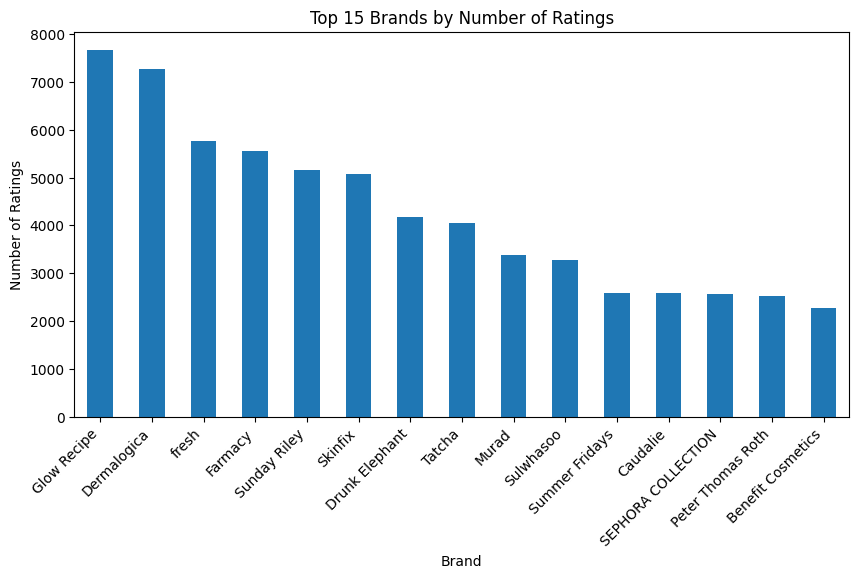

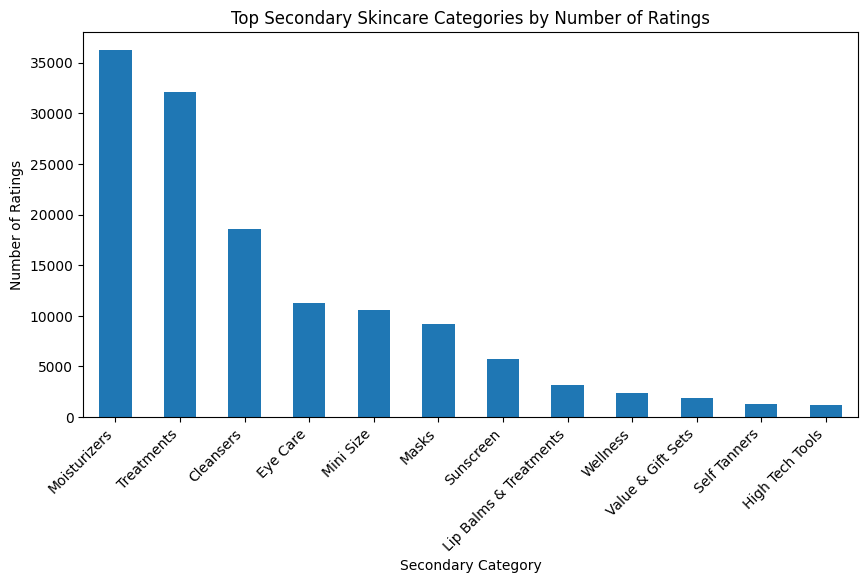

In [52]:
plt.figure(figsize=(10, 5))
df_cf_with_meta["brand_name"].value_counts().head(15).plot(kind="bar")
plt.title("Top 15 Brands by Number of Ratings")
plt.xlabel("Brand")
plt.ylabel("Number of Ratings")
plt.xticks(rotation=45, ha="right")
plt.show()

plt.figure(figsize=(10, 5))
df_cf_with_meta["secondary_category"].value_counts().head(15).plot(kind="bar")
plt.title("Top Secondary Skincare Categories by Number of Ratings")
plt.xlabel("Secondary Category")
plt.ylabel("Number of Ratings")
plt.xticks(rotation=45, ha="right")
plt.show()

In [53]:
brand_summary = (
    df_cf_with_meta
    .groupby("brand_name")
    .agg(
        mean_rating=("rating", "mean"),
        rating_count=("rating", "count"),
        unique_products=("product_id", "nunique")
    )
    .reset_index()
)

brand_summary_filtered = brand_summary[brand_summary["rating_count"] >= 100]

print("Top brands by average rating, minimum 100 ratings:")
brand_summary_filtered.sort_values("mean_rating", ascending=False).head(15)

Top brands by average rating, minimum 100 ratings:


,brand_name,mean_rating,rating_count,unique_products
71,MARA,4.910095,634,9
16,DAMDAM,4.836000,500,7
108,StriVectin,4.788760,516,19
32,FaceGym,4.782609,621,16
28,EADEM,4.782609,253,3
46,Hanni,4.778378,370,3
19,Dermalogica,4.771040,7272,43
7,Bobbi Brown,4.770963,1443,6
87,Paula's Choice,4.758107,2282,34
136,innisfree,4.753805,1117,8


In [54]:
category_summary = (
    df_cf_with_meta
    .groupby("secondary_category")
    .agg(
        mean_rating=("rating", "mean"),
        rating_count=("rating", "count"),
        unique_products=("product_id", "nunique")
    )
    .reset_index()
)

category_summary_filtered = category_summary[category_summary["rating_count"] >= 100]

print("Top categories by average rating, minimum 100 ratings:")
category_summary_filtered.sort_values("mean_rating", ascending=False).head(15)

Top categories by average rating, minimum 100 ratings:


,secondary_category,mean_rating,rating_count,unique_products
10,Value & Gift Sets,4.714586,1906,51
2,High Tech Tools,4.564315,1205,48
7,Self Tanners,4.560000,1300,29
6,Moisturizers,4.532022,36215,435
9,Treatments,4.530648,32155,383
1,Eye Care,4.513448,11315,150
0,Cleansers,4.501130,18581,277
8,Sunscreen,4.495223,5757,84
11,Wellness,4.477609,2367,54
4,Masks,4.475504,9185,116


In [55]:
product_popularity = (
    df_cf_with_meta
    .groupby(["product_id", "product_name", "brand_name"])
    .agg(
        mean_rating=("rating", "mean"),
        rating_count=("rating", "count")
    )
    .reset_index()
    .sort_values(["rating_count", "mean_rating"], ascending=[False, False])
)

print("Most rated products:")
product_popularity.head(20)

Most rated products:


,product_id,product_name,brand_name,mean_rating,rating_count
401,P423688,Daily Microfoliant Exfoliator,Dermalogica,4.795819,1435
656,P443352,Mini Daily Microfoliant Exfoliator,Dermalogica,4.795819,1435
1563,P500633,Tea Elixir Niacinamide & Hyaluronic Acid Anti-...,fresh,4.796073,1324
60,P270594,Vitamin Enriched Face Base Priming Moisturizer,Bobbi Brown,4.796223,1271
80,P309308,Good Genes All-In-One AHA Lactic Acid Treatment,Sunday Riley,4.615238,1050
1319,P476414,5 Stars Retinol + Niacinamide Eye Serum,Sunday Riley,4.796512,1032
1669,P503936,Black Tea Anti-Aging Moisturizer with Retinol-...,fresh,4.850806,992
640,P442840,Barrier+ Triple Lipid-Peptide Face Cream,Skinfix,4.667426,878
1391,P479860,Mini Barrier+ Triple Lipid-Peptide Face Cream,Skinfix,4.667426,878
1390,P479841,Floral Recovery Overnight Mask with Squalane,fresh,4.815166,844


In [56]:
important_content_cols = [
    "product_name",
    "brand_name",
    "ingredients",
    "highlights",
    "secondary_category",
    "tertiary_category",
    "price_usd",
    "review_text",
    "review_title",
    "skin_type",
    "skin_tone",
    "eye_color",
    "hair_color"
]

important_content_cols = [col for col in important_content_cols if col in df_merged.columns]

missing_content_summary = (
    df_merged[important_content_cols]
    .isna()
    .sum()
    .sort_values(ascending=False)
)

missing_content_pct = (
    df_merged[important_content_cols]
    .isna()
    .mean()
    .mul(100)
    .round(2)
    .sort_values(ascending=False)
)

content_missing_table = pd.DataFrame({
    "missing_count": missing_content_summary,
    "missing_percent": missing_content_pct
})

content_missing_table

,missing_count,missing_percent
review_title,310654,28.39
hair_color,226768,20.72
eye_color,209628,19.15
skin_tone,170539,15.58
tertiary_category,161256,14.73
highlights,113936,10.41
skin_type,111557,10.19
ingredients,22025,2.01
review_text,1444,0.13
product_name,0,0.00


Review text length summary:
count    1.094411e+06
mean     3.201541e+02
std      2.315846e+02
min      0.000000e+00
25%      1.710000e+02
50%      2.630000e+02
75%      4.020000e+02
max      6.448000e+03
Name: review_text_length, dtype: float64

Review word count summary:
count    1.094411e+06
mean     6.045960e+01
std      4.350890e+01
min      0.000000e+00
25%      3.200000e+01
50%      5.000000e+01
75%      7.600000e+01
max      1.216000e+03
Name: review_word_count, dtype: float64


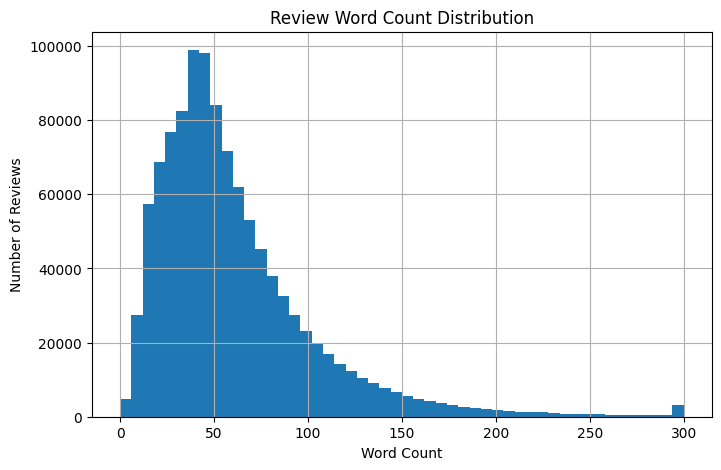

In [57]:
if "review_text" in df_merged.columns:
    df_merged["review_text_length"] = df_merged["review_text"].fillna("").str.len()
    df_merged["review_word_count"] = df_merged["review_text"].fillna("").str.split().str.len()

    print("Review text length summary:")
    print(df_merged["review_text_length"].describe())

    print("\nReview word count summary:")
    print(df_merged["review_word_count"].describe())

    plt.figure(figsize=(8, 5))
    df_merged["review_word_count"].clip(upper=300).hist(bins=50)
    plt.title("Review Word Count Distribution")
    plt.xlabel("Word Count")
    plt.ylabel("Number of Reviews")
    plt.show()

In [58]:
raw_user_counts = df_interactions["author_id"].value_counts()
raw_product_counts = df_interactions["product_id"].value_counts()

cold_start_summary = pd.DataFrame({
    "metric": [
        "Users with 1 rating",
        "Users with fewer than 5 ratings",
        "Users with fewer than 10 ratings",
        "Products with 1 rating",
        "Products with fewer than 5 ratings",
        "Products with fewer than 20 ratings"
    ],
    "count": [
        (raw_user_counts == 1).sum(),
        (raw_user_counts < 5).sum(),
        (raw_user_counts < 10).sum(),
        (raw_product_counts == 1).sum(),
        (raw_product_counts < 5).sum(),
        (raw_product_counts < 20).sum()
    ],
    "percent": [
        100 * (raw_user_counts == 1).sum() / len(raw_user_counts),
        100 * (raw_user_counts < 5).sum() / len(raw_user_counts),
        100 * (raw_user_counts < 10).sum() / len(raw_user_counts),
        100 * (raw_product_counts == 1).sum() / len(raw_product_counts),
        100 * (raw_product_counts < 5).sum() / len(raw_product_counts),
        100 * (raw_product_counts < 20).sum() / len(raw_product_counts)
    ]
})

cold_start_summary

,metric,count,percent
0,Users with 1 rating,294111,58.446274
1,Users with fewer than 5 ratings,462781,91.964683
2,Users with fewer than 10 ratings,493970,98.162618
3,Products with 1 rating,24,1.020842
4,Products with fewer than 5 ratings,127,5.401957
5,Products with fewer than 20 ratings,417,17.737133


In [59]:
# Build final modeling dataframe BEFORE summary_table

df_model = df_cf.copy()

# Make sure ID columns are strings and rating is numeric
df_model["author_id"] = df_model["author_id"].astype(str)
df_model["product_id"] = df_model["product_id"].astype(str)
df_model["rating"] = pd.to_numeric(df_model["rating"], errors="coerce")

# Drop any remaining missing values
df_model = df_model.dropna(subset=["author_id", "product_id", "rating"]).copy()

print("Final modeling dataframe shape:", df_model.shape)
print("Unique users:", df_model["author_id"].nunique())
print("Unique products:", df_model["product_id"].nunique())
print("Observed ratings:", len(df_model))

# Create full user-product matrix
user_product_matrix = df_model.pivot(
    index="author_id",
    columns="product_id",
    values="rating"
)

print("User-product matrix shape:", user_product_matrix.shape)
print("Number of users:", user_product_matrix.shape[0])
print("Number of products:", user_product_matrix.shape[1])

Final modeling dataframe shape: (133720, 3)
Unique users: 6798
Unique products: 1752
Observed ratings: 133720
User-product matrix shape: (6798, 1752)
Number of users: 6798
Number of products: 1752


In [60]:
summary_table = pd.DataFrame({
    "Stage": [
        "Raw reviews",
        "Skincare products",
        "Merged skincare reviews",
        "Deduplicated interactions",
        "Filtered collaborative filtering data",
        "User-product matrix"
    ],
    "Rows / Users": [
        len(df_reviews),
        len(df_products),
        len(df_merged),
        len(df_interactions),
        df_cf["author_id"].nunique(),
        user_product_matrix.shape[0]
    ],
    "Columns / Products": [
        df_reviews.shape[1],
        df_products.shape[1],
        df_merged.shape[1],
        df_interactions.shape[1],
        df_cf["product_id"].nunique(),
        user_product_matrix.shape[1]
    ],
    "Notes": [
        "All review files combined",
        "Filtered to primary_category == Skincare",
        "Reviews merged with skincare metadata",
        "Duplicate user-product ratings averaged",
        "Users >= 10 ratings, products >= 20 ratings",
        "Sparse matrix for recommender models"
    ]
})

summary_table

,Stage,Rows / Users,Columns / Products,Notes
0,Raw reviews,1094411,18,All review files combined
1,Skincare products,2420,27,Filtered to primary_category == Skincare
2,Merged skincare reviews,1094411,30,Reviews merged with skincare metadata
3,Deduplicated interactions,1088891,3,Duplicate user-product ratings averaged
4,Filtered collaborative filtering data,6798,1752,"Users >= 10 ratings, products >= 20 ratings"
5,User-product matrix,6798,1752,Sparse matrix for recommender models


### Build a user-product matrix 

In [61]:
# Final collaborative filtering dataframe
df_model = df_cf.copy()

# Make sure ID columns are strings and rating is numeric
df_model["author_id"] = df_model["author_id"].astype(str)
df_model["product_id"] = df_model["product_id"].astype(str)
df_model["rating"] = pd.to_numeric(df_model["rating"], errors="coerce")

# Drop any remaining missing values
df_model = df_model.dropna(subset=["author_id", "product_id", "rating"]).copy()

print("Final modeling dataframe shape:", df_model.shape)
print("Unique users:", df_model["author_id"].nunique())
print("Unique products:", df_model["product_id"].nunique())
print("Observed ratings:", len(df_model))

df_model.head()

Final modeling dataframe shape: (133720, 3)
Unique users: 6798
Unique products: 1752
Observed ratings: 133720


,author_id,product_id,rating
93,2760276,P232915,5.0
94,2760276,P309409,4.0
95,2760276,P386762,3.0
97,2760276,P420652,5.0
98,2760276,P427416,2.0


In [62]:
# Create user-product matrix
user_product_matrix = df_model.pivot(
    index="author_id",
    columns="product_id",
    values="rating"
)

print("User-product matrix shape:", user_product_matrix.shape)
print("Number of users:", user_product_matrix.shape[0])
print("Number of products:", user_product_matrix.shape[1])

user_product_matrix.head()

User-product matrix shape: (6798, 1752)
Number of users: 6798
Number of products: 1752


product_id,P107306,P114902,P12045,P122651,P122661,P122718,P122727,P122762,P122767,P122774,...,P54509,P6028,P7365,P7880,P91627362,P94421,P94812,P9939,P9940,P9941
author_id,,,,,,,,,,,,,,,,,,,,,
10000770719,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1000235057,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,5.0,NaN,NaN,NaN,NaN,NaN
10005786204,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10007009256,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1001087549,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [63]:
n_users, n_products = user_product_matrix.shape

total_cells = n_users * n_products
observed_cells = user_product_matrix.notna().sum().sum()
missing_cells = total_cells - observed_cells

density_pct = 100 * observed_cells / total_cells
sparsity_pct = 100 * missing_cells / total_cells

print("Total possible user-product cells:", total_cells)
print("Observed ratings:", observed_cells)
print("Missing cells:", missing_cells)
print(f"Density: {density_pct:.2f}%")
print(f"Sparsity: {sparsity_pct:.2f}%")

Total possible user-product cells: 11910096
Observed ratings: 133720
Missing cells: 11776376
Density: 1.12%
Sparsity: 98.88%


### Convert the dataset into train/test/validation split

In [64]:
from sklearn.model_selection import train_test_split

def user_holdout_split(
    df,
    user_col="author_id",
    item_col="product_id",
    rating_col="rating",
    train_size=0.70,
    val_size=0.15,
    test_size=0.15,
    random_state=42
):
    train_parts = []
    val_parts = []
    test_parts = []

    for user_id, user_df in df.groupby(user_col):
        user_df = user_df.sample(frac=1, random_state=random_state)

        n_ratings = len(user_df)

        # Number of ratings for validation and test
        n_test = max(1, int(round(test_size * n_ratings)))
        n_val = max(1, int(round(val_size * n_ratings)))

        # Make sure train still has at least 1 rating
        if n_ratings - n_val - n_test < 1:
            n_test = 1
            n_val = 0

        test_df = user_df.iloc[:n_test]
        val_df = user_df.iloc[n_test:n_test + n_val]
        train_df = user_df.iloc[n_test + n_val:]

        train_parts.append(train_df)
        val_parts.append(val_df)
        test_parts.append(test_df)

    train_df = pd.concat(train_parts).reset_index(drop=True)
    val_df = pd.concat(val_parts).reset_index(drop=True)
    test_df = pd.concat(test_parts).reset_index(drop=True)

    return train_df, val_df, test_df


train_df, val_df, test_df = user_holdout_split(
    df_model,
    user_col="author_id",
    item_col="product_id",
    rating_col="rating",
    train_size=0.70,
    val_size=0.15,
    test_size=0.15,
    random_state=42
)

print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)
print("Test shape:", test_df.shape)

print("\nTrain users:", train_df["author_id"].nunique())
print("Validation users:", val_df["author_id"].nunique())
print("Test users:", test_df["author_id"].nunique())

print("\nTrain products:", train_df["product_id"].nunique())
print("Validation products:", val_df["product_id"].nunique())
print("Test products:", test_df["product_id"].nunique())

Train shape: (91658, 3)
Validation shape: (21031, 3)
Test shape: (21031, 3)

Train users: 6798
Validation users: 6798
Test users: 6798

Train products: 1700
Validation products: 1517
Test products: 1465


In [65]:
total_rows = len(df_model)

split_summary = pd.DataFrame({
    "Split": ["Train", "Validation", "Test"],
    "Rows": [len(train_df), len(val_df), len(test_df)],
    "Percentage": [
        100 * len(train_df) / total_rows,
        100 * len(val_df) / total_rows,
        100 * len(test_df) / total_rows
    ],
    "Unique Users": [
        train_df["author_id"].nunique(),
        val_df["author_id"].nunique(),
        test_df["author_id"].nunique()
    ],
    "Unique Products": [
        train_df["product_id"].nunique(),
        val_df["product_id"].nunique(),
        test_df["product_id"].nunique()
    ]
})

split_summary

,Split,Rows,Percentage,Unique Users,Unique Products
0,Train,91658,68.54472,6798,1700
1,Validation,21031,15.72764,6798,1517
2,Test,21031,15.72764,6798,1465


In [66]:
train_users = set(train_df["author_id"])
val_users = set(val_df["author_id"])
test_users = set(test_df["author_id"])

print("Validation users missing from train:", len(val_users - train_users))
print("Test users missing from train:", len(test_users - train_users))

Validation users missing from train: 0
Test users missing from train: 0


In [67]:
train_products = set(train_df["product_id"])
val_products = set(val_df["product_id"])
test_products = set(test_df["product_id"])

print("Validation products missing from train:", len(val_products - train_products))
print("Test products missing from train:", len(test_products - train_products))

Validation products missing from train: 36
Test products missing from train: 25


In [68]:
# Keep only validation/test rows where product is present in training
known_train_products = set(train_df["product_id"])

val_df_clean = val_df[val_df["product_id"].isin(known_train_products)].copy()
test_df_clean = test_df[test_df["product_id"].isin(known_train_products)].copy()

print("Original validation rows:", len(val_df))
print("Clean validation rows:", len(val_df_clean))
print("Dropped validation rows:", len(val_df) - len(val_df_clean))

print("\nOriginal test rows:", len(test_df))
print("Clean test rows:", len(test_df_clean))
print("Dropped test rows:", len(test_df) - len(test_df_clean))

Original validation rows: 21031
Clean validation rows: 20990
Dropped validation rows: 41

Original test rows: 21031
Clean test rows: 20998
Dropped test rows: 33


In [69]:
val_df = val_df_clean.copy()
test_df = test_df_clean.copy()

In [70]:
train_matrix = train_df.pivot(
    index="author_id",
    columns="product_id",
    values="rating"
)

print("Train matrix shape:", train_matrix.shape)
print("Train observed ratings:", train_matrix.notna().sum().sum())

train_matrix.head()

Train matrix shape: (6798, 1700)
Train observed ratings: 91658


product_id,P107306,P114902,P12045,P122651,P122661,P122718,P122727,P122762,P122767,P122774,...,P54509,P6028,P7365,P7880,P91627362,P94421,P94812,P9939,P9940,P9941
author_id,,,,,,,,,,,,,,,,,,,,,
10000770719,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1000235057,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,5.0,NaN,NaN,NaN,NaN,NaN
10005786204,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10007009256,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1001087549,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [71]:
all_users = sorted(df_model["author_id"].unique())
all_products = sorted(df_model["product_id"].unique())

train_matrix_full = train_matrix.reindex(
    index=all_users,
    columns=all_products
)

print("Full train matrix shape:", train_matrix_full.shape)
print("Train observed ratings:", train_matrix_full.notna().sum().sum())
print("Missing values in train matrix:", train_matrix_full.isna().sum().sum())

Full train matrix shape: (6798, 1752)
Train observed ratings: 91658
Missing values in train matrix: 11818438


In [72]:
val_user_items = (
    val_df
    .groupby("author_id")["product_id"]
    .apply(list)
    .to_dict()
)

test_user_items = (
    test_df
    .groupby("author_id")["product_id"]
    .apply(list)
    .to_dict()
)

print("Users in validation dictionary:", len(val_user_items))
print("Users in test dictionary:", len(test_user_items))

Users in validation dictionary: 6798
Users in test dictionary: 6798


In [73]:
sample_user = list(test_user_items.keys())[0]

print("Sample user:", sample_user)
print("Held-out test products:", test_user_items[sample_user])

Sample user: 10000770719
Held-out test products: ['P464233', 'P447212']


In [74]:
val_actual = val_df.set_index(["author_id", "product_id"])["rating"].to_dict()
test_actual = test_df.set_index(["author_id", "product_id"])["rating"].to_dict()

print("Validation actual ratings:", len(val_actual))
print("Test actual ratings:", len(test_actual))

Validation actual ratings: 20990
Test actual ratings: 20998


In [75]:
train_df.to_csv("train_interactions.csv", index=False)
val_df.to_csv("val_interactions.csv", index=False)
test_df.to_csv("test_interactions.csv", index=False)

print("Saved train, validation, and test interaction files.")

Saved train, validation, and test interaction files.


In [76]:
print("Final sanity check")
print("=" * 40)

print("Original df_model rows:", len(df_model))
print("Train + val + test rows:", len(train_df) + len(val_df) + len(test_df))

print("\nTrain users:", train_df["author_id"].nunique())
print("Validation users:", val_df["author_id"].nunique())
print("Test users:", test_df["author_id"].nunique())

print("\nTrain products:", train_df["product_id"].nunique())
print("Validation products:", val_df["product_id"].nunique())
print("Test products:", test_df["product_id"].nunique())

print("\nValidation users missing from train:", len(set(val_df["author_id"]) - set(train_df["author_id"])))
print("Test users missing from train:", len(set(test_df["author_id"]) - set(train_df["author_id"])))

print("\nValidation products missing from train:", len(set(val_df["product_id"]) - set(train_df["product_id"])))
print("Test products missing from train:", len(set(test_df["product_id"]) - set(train_df["product_id"])))

Final sanity check
Original df_model rows: 133720
Train + val + test rows: 133646

Train users: 6798
Validation users: 6798
Test users: 6798

Train products: 1700
Validation products: 1481
Test products: 1440

Validation users missing from train: 0
Test users missing from train: 0

Validation products missing from train: 0
Test products missing from train: 0


### Baseline Model

Predicted rating = overall average rating + how generous the user is + how popular the product is + brand/category effect.

In [77]:
# Product metadata columns we may use
metadata_cols = [
    "product_id",
    "brand_name",
    "primary_category",
    "secondary_category",
    "tertiary_category"
]

metadata_cols = [col for col in metadata_cols if col in df_merged.columns]

product_meta = (
    df_merged[metadata_cols]
    .drop_duplicates(subset=["product_id"])
    .copy()
)

product_meta["product_id"] = product_meta["product_id"].astype(str)

print("Product metadata shape:", product_meta.shape)
product_meta.head()

Product metadata shape: (2351, 5)


,product_id,brand_name,primary_category,secondary_category,tertiary_category
0,P504322,NUDESTIX,Skincare,Cleansers,NaN
1,P420652,LANEIGE,Skincare,Lip Balms & Treatments,NaN
16139,P7880,fresh,Skincare,Cleansers,Face Wash & Cleansers
24875,P218700,Josie Maran,Skincare,Moisturizers,Face Oils
32638,P248407,First Aid Beauty,Skincare,Moisturizers,Moisturizers


In [78]:
train_base = train_df.merge(product_meta, on="product_id", how="left")
val_base = val_df.merge(product_meta, on="product_id", how="left")
test_base = test_df.merge(product_meta, on="product_id", how="left")

print("Train with metadata:", train_base.shape)
print("Validation with metadata:", val_base.shape)
print("Test with metadata:", test_base.shape)

train_base.head()

Train with metadata: (91658, 7)
Validation with metadata: (20990, 7)
Test with metadata: (20998, 7)


,author_id,product_id,rating,brand_name,primary_category,secondary_category,tertiary_category
0,10000770719,P454936,5.0,Dr. Barbara Sturm,Skincare,Mini Size,NaN
1,10000770719,P447781,5.0,Dr. Barbara Sturm,Skincare,Moisturizers,Moisturizers
2,10000770719,P501254,5.0,Glow Recipe,Skincare,Treatments,Facial Peels
3,10000770719,P447785,5.0,Dr. Barbara Sturm,Skincare,Eye Care,Eye Creams & Treatments
4,10000770719,P447782,5.0,Dr. Barbara Sturm,Skincare,Treatments,Face Serums


In [79]:
cols_to_check = [
    "brand_name",
    "primary_category",
    "secondary_category",
    "tertiary_category"
]

cols_to_check = [col for col in cols_to_check if col in train_base.columns]

print("Missing values in train metadata:")
print(train_base[cols_to_check].isna().sum())

print("\nMissing values in validation metadata:")
print(val_base[cols_to_check].isna().sum())

print("\nMissing values in test metadata:")
print(test_base[cols_to_check].isna().sum())

Missing values in train metadata:
brand_name                0
primary_category          0
secondary_category        0
tertiary_category     11501
dtype: int64

Missing values in validation metadata:
brand_name               0
primary_category         0
secondary_category       0
tertiary_category     2374
dtype: int64

Missing values in test metadata:
brand_name               0
primary_category         0
secondary_category       0
tertiary_category     2468
dtype: int64


In [80]:
for df in [train_base, val_base, test_base]:
    for col in cols_to_check:
        df[col] = df[col].fillna("Unknown")

In [81]:
global_mean = train_base["rating"].mean()

print("Global mean rating:", global_mean)

Global mean rating: 4.513922225374035


In [82]:
prediction = global_mean

In [83]:
user_bias = (
    train_base
    .groupby("author_id")["rating"]
    .mean()
    - global_mean
)

user_bias = user_bias.to_dict()

print("Number of user biases:", len(user_bias))

# Show sample
list(user_bias.items())[:5]

Number of user biases: 6798


[('10000770719', 0.486077774625965),
 ('1000235057', -1.0639222253740348),
 ('10005786204', -0.513922225374035),
 ('10007009256', 0.486077774625965),
 ('1001087549', 0.357045516561449)]

In [84]:
product_bias = (
    train_base
    .groupby("product_id")["rating"]
    .mean()
    - global_mean
)

product_bias = product_bias.to_dict()

print("Number of product biases:", len(product_bias))

# Show sample
list(product_bias.items())[:5]

Number of product biases: 1700


[('P107306', -0.01392222537403498),
 ('P114902', -0.01392222537403498),
 ('P12045', 0.015489539331847268),
 ('P122651', -1.513922225374035),
 ('P122661', -0.11392222537403462)]

In [85]:
def compute_smoothed_bias(df, group_col, rating_col="rating", global_mean=None, alpha=20):
    """
    Smoothed bias:
    group_bias = (sum_ratings - n * global_mean) / (n + alpha)

    alpha controls shrinkage:
    - larger alpha pulls small groups closer to 0
    - smaller alpha trusts group averages more
    """
    if global_mean is None:
        global_mean = df[rating_col].mean()
    
    group_stats = (
        df
        .groupby(group_col)[rating_col]
        .agg(["sum", "count"])
    )
    
    group_stats["bias"] = (
        group_stats["sum"] - group_stats["count"] * global_mean
    ) / (group_stats["count"] + alpha)
    
    return group_stats["bias"].to_dict()

In [86]:
brand_bias = compute_smoothed_bias(
    train_base,
    group_col="brand_name",
    rating_col="rating",
    global_mean=global_mean,
    alpha=20
)

print("Number of brand biases:", len(brand_bias))
list(brand_bias.items())[:5]

Number of brand biases: 139


[('Algenist', -0.01352726862583524),
 ('Alpha-H', -0.010054940547913956),
 ('Anastasia Beverly Hills', 0.044188888602360456),
 ('Augustinus Bader', -0.20691933896182269),
 ('BeautyBio', -0.02900315738044605)]

In [87]:
category_col = "secondary_category"

category_bias = compute_smoothed_bias(
    train_base,
    group_col=category_col,
    rating_col="rating",
    global_mean=global_mean,
    alpha=20
)

print("Category column used:", category_col)
print("Number of category biases:", len(category_bias))
list(category_bias.items())[:5]

Category column used: secondary_category
Number of category biases: 12


[('Cleansers', -0.014525554620629112),
 ('Eye Care', 0.01009547769636288),
 ('High Tech Tools', -0.004781867550908444),
 ('Lip Balms & Treatments', -0.02715004161384382),
 ('Masks', -0.04444695767933047)]

In [88]:
def predict_baseline(
    df,
    global_mean,
    user_bias,
    product_bias,
    brand_bias=None,
    category_bias=None,
    category_col="secondary_category",
    use_user=True,
    use_product=True,
    use_brand=True,
    use_category=True,
    min_rating=1.0,
    max_rating=5.0
):
    preds = []

    for _, row in df.iterrows():
        pred = global_mean

        if use_user:
            pred += user_bias.get(row["author_id"], 0)

        if use_product:
            pred += product_bias.get(row["product_id"], 0)

        if use_brand and brand_bias is not None:
            pred += brand_bias.get(row["brand_name"], 0)

        if use_category and category_bias is not None:
            pred += category_bias.get(row[category_col], 0)

        # Clip predictions to valid Sephora rating range
        pred = min(max(pred, min_rating), max_rating)

        preds.append(pred)

    return np.array(preds)

In [89]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

def evaluate_predictions(y_true, y_pred, model_name="Model"):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)

    print(f"{model_name}")
    print("-" * 40)
    print(f"RMSE: {rmse:.4f}")
    print(f"MAE : {mae:.4f}")
    
    return rmse, mae

In [90]:
val_pred_global = np.full(len(val_base), global_mean)
test_pred_global = np.full(len(test_base), global_mean)

val_global_rmse, val_global_mae = evaluate_predictions(
    val_base["rating"],
    val_pred_global,
    model_name="Validation: Global Mean Baseline"
)

test_global_rmse, test_global_mae = evaluate_predictions(
    test_base["rating"],
    test_pred_global,
    model_name="Test: Global Mean Baseline"
)

Validation: Global Mean Baseline
----------------------------------------
RMSE: 0.9245
MAE : 0.6893
Test: Global Mean Baseline
----------------------------------------
RMSE: 0.9292
MAE : 0.6902


In [91]:
val_pred_user = predict_baseline(
    val_base,
    global_mean=global_mean,
    user_bias=user_bias,
    product_bias=product_bias,
    brand_bias=brand_bias,
    category_bias=category_bias,
    category_col=category_col,
    use_user=True,
    use_product=False,
    use_brand=False,
    use_category=False
)

test_pred_user = predict_baseline(
    test_base,
    global_mean=global_mean,
    user_bias=user_bias,
    product_bias=product_bias,
    brand_bias=brand_bias,
    category_bias=category_bias,
    category_col=category_col,
    use_user=True,
    use_product=False,
    use_brand=False,
    use_category=False
)

val_user_rmse, val_user_mae = evaluate_predictions(
    val_base["rating"],
    val_pred_user,
    model_name="Validation: Global Mean + User Bias"
)

test_user_rmse, test_user_mae = evaluate_predictions(
    test_base["rating"],
    test_pred_user,
    model_name="Test: Global Mean + User Bias"
)

Validation: Global Mean + User Bias
----------------------------------------
RMSE: 0.8109
MAE : 0.5048
Test: Global Mean + User Bias
----------------------------------------
RMSE: 0.8105
MAE : 0.5004


In [92]:
val_pred_user_product = predict_baseline(
    val_base,
    global_mean=global_mean,
    user_bias=user_bias,
    product_bias=product_bias,
    brand_bias=brand_bias,
    category_bias=category_bias,
    category_col=category_col,
    use_user=True,
    use_product=True,
    use_brand=False,
    use_category=False
)

test_pred_user_product = predict_baseline(
    test_base,
    global_mean=global_mean,
    user_bias=user_bias,
    product_bias=product_bias,
    brand_bias=brand_bias,
    category_bias=category_bias,
    category_col=category_col,
    use_user=True,
    use_product=True,
    use_brand=False,
    use_category=False
)

val_up_rmse, val_up_mae = evaluate_predictions(
    val_base["rating"],
    val_pred_user_product,
    model_name="Validation: Global Mean + User Bias + Product Bias"
)

test_up_rmse, test_up_mae = evaluate_predictions(
    test_base["rating"],
    test_pred_user_product,
    model_name="Test: Global Mean + User Bias + Product Bias"
)

Validation: Global Mean + User Bias + Product Bias
----------------------------------------
RMSE: 0.8406
MAE : 0.5220
Test: Global Mean + User Bias + Product Bias
----------------------------------------
RMSE: 0.8399
MAE : 0.5174


In [93]:
val_pred_full_baseline = predict_baseline(
    val_base,
    global_mean=global_mean,
    user_bias=user_bias,
    product_bias=product_bias,
    brand_bias=brand_bias,
    category_bias=category_bias,
    category_col=category_col,
    use_user=True,
    use_product=True,
    use_brand=True,
    use_category=True
)

test_pred_full_baseline = predict_baseline(
    test_base,
    global_mean=global_mean,
    user_bias=user_bias,
    product_bias=product_bias,
    brand_bias=brand_bias,
    category_bias=category_bias,
    category_col=category_col,
    use_user=True,
    use_product=True,
    use_brand=True,
    use_category=True
)

val_full_rmse, val_full_mae = evaluate_predictions(
    val_base["rating"],
    val_pred_full_baseline,
    model_name="Validation: Full Bias Baseline"
)

test_full_rmse, test_full_mae = evaluate_predictions(
    test_base["rating"],
    test_pred_full_baseline,
    model_name="Test: Full Bias Baseline"
)

Validation: Full Bias Baseline
----------------------------------------
RMSE: 0.8911
MAE : 0.5576
Test: Full Bias Baseline
----------------------------------------
RMSE: 0.8880
MAE : 0.5515


In [94]:
baseline_results = pd.DataFrame({
    "Model": [
        "Global Mean",
        "Global Mean + User Bias",
        "Global Mean + User + Product Bias",
        "Full Bias Baseline: User + Product + Brand + Category"
    ],
    "Validation RMSE": [
        val_global_rmse,
        val_user_rmse,
        val_up_rmse,
        val_full_rmse
    ],
    "Validation MAE": [
        val_global_mae,
        val_user_mae,
        val_up_mae,
        val_full_mae
    ],
    "Test RMSE": [
        test_global_rmse,
        test_user_rmse,
        test_up_rmse,
        test_full_rmse
    ],
    "Test MAE": [
        test_global_mae,
        test_user_mae,
        test_up_mae,
        test_full_mae
    ]
})

baseline_results.sort_values("Validation RMSE")

,Model,Validation RMSE,Validation MAE,Test RMSE,Test MAE
1,Global Mean + User Bias,0.810862,0.504832,0.810492,0.500450
2,Global Mean + User + Product Bias,0.840576,0.522025,0.839859,0.517411
3,Full Bias Baseline: User + Product + Brand + C...,0.891056,0.557556,0.888047,0.551510
0,Global Mean,0.924515,0.689334,0.929222,0.690179


In [95]:
val_baseline_predictions = val_base[["author_id", "product_id", "rating"]].copy()
val_baseline_predictions["baseline_pred"] = val_pred_full_baseline

test_baseline_predictions = test_base[["author_id", "product_id", "rating"]].copy()
test_baseline_predictions["baseline_pred"] = test_pred_full_baseline

print("Validation baseline predictions:")
display(val_baseline_predictions.head())

print("Test baseline predictions:")
display(test_baseline_predictions.head())

Validation baseline predictions:


,author_id,product_id,rating,baseline_pred
0,10000770719,P448203,5.0,4.904510
1,10000770719,P404338,4.0,4.716216
2,1000235057,P126301,1.0,2.859089
3,1000235057,P421275,5.0,3.328110
4,1000235057,P432049,1.0,3.659580


Test baseline predictions:


,author_id,product_id,rating,baseline_pred
0,10000770719,P464233,5.0,4.213304
1,10000770719,P447212,5.0,3.927409
2,1000235057,P409631,2.0,2.336903
3,1000235057,P461667,5.0,2.194222
4,1000235057,P397890,5.0,3.084892


In [96]:
user_bias_df = pd.DataFrame({
    "author_id": list(user_bias.keys()),
    "user_bias": list(user_bias.values())
}).sort_values("user_bias", ascending=False)

product_bias_df = pd.DataFrame({
    "product_id": list(product_bias.keys()),
    "product_bias": list(product_bias.values())
}).sort_values("product_bias", ascending=False)

brand_bias_df = pd.DataFrame({
    "brand_name": list(brand_bias.keys()),
    "brand_bias": list(brand_bias.values())
}).sort_values("brand_bias", ascending=False)

category_bias_df = pd.DataFrame({
    category_col: list(category_bias.keys()),
    "category_bias": list(category_bias.values())
}).sort_values("category_bias", ascending=False)

print("Most generous users:")
display(user_bias_df.head())

print("Highest product effects:")
display(product_bias_df.head())

print("Highest brand effects:")
display(brand_bias_df.head())

print("Highest category effects:")
display(category_bias_df.head())

Most generous users:


,author_id,user_bias
0,10000770719,0.486078
3386,26863550525,0.486078
3320,2641914751,0.486078
3322,2641965935,0.486078
3327,2643282265,0.486078


Highest product effects:


,product_id,product_bias
742,P449150,0.486078
1436,P482510,0.486078
1082,P469512,0.486078
1465,P483496,0.486078
821,P455242,0.486078


Highest brand effects:


,brand_name,brand_bias
71,MARA,0.386245
16,DAMDAM,0.306019
108,StriVectin,0.275028
87,Paula's Choice,0.257156
19,Dermalogica,0.254342


Highest category effects:


,secondary_category,category_bias
10,Value & Gift Sets,0.214803
7,Self Tanners,0.046961
6,Moisturizers,0.014119
9,Treatments,0.012410
1,Eye Care,0.010095


In [97]:
product_name_cols = ["product_id", "product_name", "brand_name"]

product_name_cols = [col for col in product_name_cols if col in df_merged.columns]

product_names = (
    df_merged[product_name_cols]
    .drop_duplicates(subset=["product_id"])
    .copy()
)

product_names["product_id"] = product_names["product_id"].astype(str)

product_bias_named = product_bias_df.merge(
    product_names,
    on="product_id",
    how="left"
)

print("Products with highest positive bias:")
display(product_bias_named.head(15))

print("Products with lowest product bias:")
display(product_bias_named.tail(15))

Products with highest positive bias:


,product_id,product_bias,product_name,brand_name
0,P449150,0.486078,Hydrating Oil,Anastasia Beverly Hills
1,P482510,0.486078,The Ultimate Soothing Cream,Augustinus Bader
2,P469512,0.486078,CLINICAL Ceramide-Enriched Firming Eye Cream,Paula's Choice
3,P483496,0.486078,Salicylic Acid 2% Exfoliating Blemish Solution,The Ordinary
4,P455242,0.486078,Super Amino Gel Cleanser,Summer Fridays
5,P406529,0.486078,Advanced Night Micro Cleansing Balm,Estée Lauder
6,P407444,0.486078,Bamboo Charcoal Detoxifying Soap Bar,Herbivore
7,P469516,0.486078,CLEAR Ultra-Light Daily Hydrating Fluid SPF 30+,Paula's Choice
8,P408241,0.486078,Plantscription Youth-Renewing Power Night Cream,Origins
9,P482681,0.486078,Bye Bye Makeup 3-in-1 Makeup Melting Cleansing...,IT Cosmetics


Products with lowest product bias:


,product_id,product_bias,product_name,brand_name
1685,P446909,-2.513922,Zincscreen 100% Mineral Sunscreen Lotion SPF 4...,Supergoop!
1686,P421271,-2.513922,Wrinkle Warrior Eye Gel Visible Dark Circle Er...,Kate Somerville
1687,P417111,-2.513922,The Eye Balm Intense,La Mer
1688,P415773,-2.513922,Pep-Start Daily UV Protector Broad Spectrum SP...,CLINIQUE
1689,P500982,-2.513922,Water Bank Cleansing Foam,LANEIGE
1690,P459127,-2.763922,Platinum Lip Plump SPF 30,Dr. Lara Devgan Scientific Beauty
1691,P444967,-3.013922,"Mini Facial Spray with Aloe, Herbs and Rosewater",Mario Badescu
1692,P460010,-3.013922,Prep & Plane Facial Razors,TWEEZERMAN
1693,P479732,-3.513922,Salicylic Acid 2% Anhydrous Solution Pore Clea...,The Ordinary
1694,P432835,-3.513922,Rose Quartz Facial De-Puffing & Lifting Gua Sha,KORA Organics


In [98]:
def recommend_baseline_for_user(
    user_id,
    train_df,
    product_meta,
    global_mean,
    user_bias,
    product_bias,
    brand_bias,
    category_bias,
    category_col="secondary_category",
    top_n=10
):
    user_id = str(user_id)

    # Products already rated by user in training
    rated_products = set(
        train_df.loc[train_df["author_id"] == user_id, "product_id"]
    )

    # Candidate products not rated by this user
    candidates = product_meta[~product_meta["product_id"].isin(rated_products)].copy()
    candidates["author_id"] = user_id

    # Predict ratings
    candidates["predicted_rating"] = predict_baseline(
        candidates,
        global_mean=global_mean,
        user_bias=user_bias,
        product_bias=product_bias,
        brand_bias=brand_bias,
        category_bias=category_bias,
        category_col=category_col,
        use_user=True,
        use_product=True,
        use_brand=True,
        use_category=True
    )

    # Add product names if available
    display_cols = [
        "product_id",
        "product_name",
        "brand_name",
        "secondary_category",
        "tertiary_category",
        "predicted_rating"
    ]

    display_cols = [col for col in display_cols if col in candidates.columns]

    return (
        candidates
        .sort_values("predicted_rating", ascending=False)
        .head(top_n)[display_cols]
    )

In [99]:
sample_user = train_df["author_id"].iloc[0]

recommend_baseline_for_user(
    user_id=sample_user,
    train_df=train_df,
    product_meta=product_meta.merge(
        df_merged[["product_id", "product_name"]].drop_duplicates("product_id"),
        on="product_id",
        how="left"
    ) if "product_name" not in product_meta.columns and "product_name" in df_merged.columns else product_meta,
    global_mean=global_mean,
    user_bias=user_bias,
    product_bias=product_bias,
    brand_bias=brand_bias,
    category_bias=category_bias,
    category_col=category_col,
    top_n=10
)

,product_id,product_name,brand_name,secondary_category,tertiary_category,predicted_rating
2350,P505392,Multi Action Clear Acne Clearing Treatment Lot...,StriVectin,Treatments,Blemish & Acne Treatments,5.0
664,P476415,Acne+ 2% BHA + Azelaic Acid + Niacinamide + AH...,Skinfix,Cleansers,Face Wash & Cleansers,5.0
1364,P475172,Overnight Vitalizing Mask,Sulwhasoo,Masks,Face Masks,5.0
1363,P464244,Vitamin C Brightening Toner,Dr. Zenovia Skincare,Cleansers,Toners,5.0
1361,P417625,24/7 Retinol Eye Cream,Dr. Brandt Skincare,Eye Care,Eye Creams & Treatments,5.0
670,P423142,Active Moist Moisturizer,Dermalogica,Moisturizers,Moisturizers,5.0
1359,P504988,Snow Mushroom Pore Cleanser with Exfoliating G...,DAMDAM,Cleansers,NaN,5.0
1358,P483701,Daily Essentials Travel Set,The Outset,Value & Gift Sets,NaN,5.0
673,P474340,Santorini Grape Velvet Skin Drink,KORRES,Moisturizers,Face Oils,5.0
1353,P501421,Dew Dream- Hydrating Makeup Removing Cleansing...,EADEM,Cleansers,Face Wash & Cleansers,5.0


In [100]:
# Save best baseline predictions: Global Mean + User Bias

val_best_baseline_predictions = val_base[["author_id", "product_id", "rating"]].copy()
val_best_baseline_predictions["baseline_pred"] = val_pred_user

test_best_baseline_predictions = test_base[["author_id", "product_id", "rating"]].copy()
test_best_baseline_predictions["baseline_pred"] = test_pred_user

print("Validation best baseline predictions:")
display(val_best_baseline_predictions.head())

print("Test best baseline predictions:")
display(test_best_baseline_predictions.head())

Validation best baseline predictions:


,author_id,product_id,rating,baseline_pred
0,10000770719,P448203,5.0,5.00
1,10000770719,P404338,4.0,5.00
2,1000235057,P126301,1.0,3.45
3,1000235057,P421275,5.0,3.45
4,1000235057,P432049,1.0,3.45


Test best baseline predictions:


,author_id,product_id,rating,baseline_pred
0,10000770719,P464233,5.0,5.00
1,10000770719,P447212,5.0,5.00
2,1000235057,P409631,2.0,3.45
3,1000235057,P461667,5.0,3.45
4,1000235057,P397890,5.0,3.45


### Matrix factorisation

In [101]:
# Use only train users/products
user_ids = train_df["author_id"].unique()
product_ids = train_df["product_id"].unique()

user_to_idx = {u: i for i, u in enumerate(user_ids)}
product_to_idx = {p: i for i, p in enumerate(product_ids)}

idx_to_user = {i: u for u, i in user_to_idx.items()}
idx_to_product = {i: p for p, i in product_to_idx.items()}

n_users = len(user_to_idx)
n_products = len(product_to_idx)

print("Train users:", n_users)
print("Train products:", n_products)

Train users: 6798
Train products: 1700


In [102]:
def prepare_mf_data(df, user_to_idx, product_to_idx):
    df_known = df[
        df["author_id"].isin(user_to_idx) &
        df["product_id"].isin(product_to_idx)
    ].copy()
    
    user_idx = df_known["author_id"].map(user_to_idx).values
    product_idx = df_known["product_id"].map(product_to_idx).values
    ratings = df_known["rating"].values.astype(float)
    
    return user_idx, product_idx, ratings, df_known

train_u, train_i, train_r, train_mf = prepare_mf_data(train_df, user_to_idx, product_to_idx)
val_u, val_i, val_r, val_mf = prepare_mf_data(val_df, user_to_idx, product_to_idx)
test_u, test_i, test_r, test_mf = prepare_mf_data(test_df, user_to_idx, product_to_idx)

print("Train ratings:", len(train_r))
print("Validation ratings:", len(val_r))
print("Test ratings:", len(test_r))

Train ratings: 91658
Validation ratings: 20990
Test ratings: 20998


In [103]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error

def train_matrix_factorization(
    train_u, train_i, train_r,
    val_u, val_i, val_r,
    n_users, n_products,
    n_factors=30,
    lr=0.01,
    reg=0.05,
    n_epochs=20,
    random_state=42
):
    np.random.seed(random_state)
    
    global_mean = train_r.mean()
    user_bias = np.zeros(n_users)
    item_bias = np.zeros(n_products)
    
    P = 0.01 * np.random.randn(n_users, n_factors)
    Q = 0.01 * np.random.randn(n_products, n_factors)
    
    history = []
    
    for epoch in range(n_epochs):
        order = np.random.permutation(len(train_r))
        
        for idx in order:
            u = train_u[idx]
            i = train_i[idx]
            r = train_r[idx]
            
            pred = global_mean + user_bias[u] + item_bias[i] + np.dot(P[u], Q[i])
            err = r - pred
            
            user_bias[u] += lr * (err - reg * user_bias[u])
            item_bias[i] += lr * (err - reg * item_bias[i])
            
            P_old = P[u].copy()
            P[u] += lr * (err * Q[i] - reg * P[u])
            Q[i] += lr * (err * P_old - reg * Q[i])
        
        val_pred = global_mean + user_bias[val_u] + item_bias[val_i] + np.sum(P[val_u] * Q[val_i], axis=1)
        val_pred = np.clip(val_pred, 1, 5)
        
        val_rmse = np.sqrt(mean_squared_error(val_r, val_pred))
        val_mae = mean_absolute_error(val_r, val_pred)
        
        history.append([epoch + 1, val_rmse, val_mae])
        print(f"Epoch {epoch+1:02d} | Val RMSE: {val_rmse:.4f} | Val MAE: {val_mae:.4f}")
    
    return global_mean, user_bias, item_bias, P, Q, pd.DataFrame(history, columns=["epoch", "val_rmse", "val_mae"])

In [104]:
mf_global, mf_user_bias, mf_item_bias, P, Q, mf_history = train_matrix_factorization(
    train_u, train_i, train_r,
    val_u, val_i, val_r,
    n_users=n_users,
    n_products=n_products,
    n_factors=30,
    lr=0.01,
    reg=0.05,
    n_epochs=20,
    random_state=42
)

Epoch 01 | Val RMSE: 0.8617 | Val MAE: 0.6062
Epoch 02 | Val RMSE: 0.8404 | Val MAE: 0.5815
Epoch 03 | Val RMSE: 0.8278 | Val MAE: 0.5657
Epoch 04 | Val RMSE: 0.8194 | Val MAE: 0.5558
Epoch 05 | Val RMSE: 0.8130 | Val MAE: 0.5471
Epoch 06 | Val RMSE: 0.8082 | Val MAE: 0.5399
Epoch 07 | Val RMSE: 0.8050 | Val MAE: 0.5366
Epoch 08 | Val RMSE: 0.8029 | Val MAE: 0.5315
Epoch 09 | Val RMSE: 0.8002 | Val MAE: 0.5279
Epoch 10 | Val RMSE: 0.7986 | Val MAE: 0.5245
Epoch 11 | Val RMSE: 0.7975 | Val MAE: 0.5212
Epoch 12 | Val RMSE: 0.7969 | Val MAE: 0.5201
Epoch 13 | Val RMSE: 0.7958 | Val MAE: 0.5177
Epoch 14 | Val RMSE: 0.7954 | Val MAE: 0.5169
Epoch 15 | Val RMSE: 0.7953 | Val MAE: 0.5148
Epoch 16 | Val RMSE: 0.7947 | Val MAE: 0.5128
Epoch 17 | Val RMSE: 0.7946 | Val MAE: 0.5134
Epoch 18 | Val RMSE: 0.7937 | Val MAE: 0.5103
Epoch 19 | Val RMSE: 0.7939 | Val MAE: 0.5105
Epoch 20 | Val RMSE: 0.7932 | Val MAE: 0.5094


In [105]:
def predict_mf(user_idx, item_idx, global_mean, user_bias, item_bias, P, Q):
    preds = global_mean + user_bias[user_idx] + item_bias[item_idx] + np.sum(P[user_idx] * Q[item_idx], axis=1)
    return np.clip(preds, 1, 5)

val_pred_mf = predict_mf(val_u, val_i, mf_global, mf_user_bias, mf_item_bias, P, Q)
test_pred_mf = predict_mf(test_u, test_i, mf_global, mf_user_bias, mf_item_bias, P, Q)

val_mf_rmse = np.sqrt(mean_squared_error(val_r, val_pred_mf))
val_mf_mae = mean_absolute_error(val_r, val_pred_mf)

test_mf_rmse = np.sqrt(mean_squared_error(test_r, test_pred_mf))
test_mf_mae = mean_absolute_error(test_r, test_pred_mf)

print("Matrix Factorization with Biases")
print("-" * 40)
print(f"Validation RMSE: {val_mf_rmse:.4f}")
print(f"Validation MAE : {val_mf_mae:.4f}")
print(f"Test RMSE      : {test_mf_rmse:.4f}")
print(f"Test MAE       : {test_mf_mae:.4f}")

Matrix Factorization with Biases
----------------------------------------
Validation RMSE: 0.7932
Validation MAE : 0.5094
Test RMSE      : 0.7946
Test MAE       : 0.5054


In [106]:
model_comparison = pd.DataFrame({
    "Model": [
        "Best Baseline: Global Mean + User Bias",
        "Matrix Factorization with Biases"
    ],
    "Validation RMSE": [
        val_user_rmse,
        val_mf_rmse
    ],
    "Validation MAE": [
        val_user_mae,
        val_mf_mae
    ],
    "Test RMSE": [
        test_user_rmse,
        test_mf_rmse
    ],
    "Test MAE": [
        test_user_mae,
        test_mf_mae
    ]
})

model_comparison

,Model,Validation RMSE,Validation MAE,Test RMSE,Test MAE
0,Best Baseline: Global Mean + User Bias,0.810862,0.504832,0.810492,0.50045
1,Matrix Factorization with Biases,0.793229,0.509448,0.794603,0.50539


In [107]:
val_improvement = val_user_rmse - val_mf_rmse
test_improvement = test_user_rmse - test_mf_rmse

print(f"Validation RMSE improvement: {val_improvement:.4f}")
print(f"Test RMSE improvement: {test_improvement:.4f}")
print(f"Validation % improvement: {100 * val_improvement / val_user_rmse:.2f}%")
print(f"Test % improvement: {100 * test_improvement / test_user_rmse:.2f}%")

Validation RMSE improvement: 0.0176
Test RMSE improvement: 0.0159
Validation % improvement: 2.17%
Test % improvement: 1.96%


In [108]:
val_mf_predictions = val_mf[["author_id", "product_id", "rating"]].copy()
val_mf_predictions["mf_pred"] = val_pred_mf

test_mf_predictions = test_mf[["author_id", "product_id", "rating"]].copy()
test_mf_predictions["mf_pred"] = test_pred_mf

display(val_mf_predictions.head())
display(test_mf_predictions.head())

,author_id,product_id,rating,mf_pred
0,10000770719,P448203,5.0,4.923726
1,10000770719,P404338,4.0,4.828605
2,1000235057,P126301,1.0,3.969739
3,1000235057,P421275,5.0,3.635450
4,1000235057,P432049,1.0,3.769142


,author_id,product_id,rating,mf_pred
0,10000770719,P464233,5.0,4.793759
1,10000770719,P447212,5.0,4.488099
2,1000235057,P409631,2.0,3.429696
3,1000235057,P461667,5.0,3.280804
4,1000235057,P397890,5.0,3.885473


Matrix factorization with biases improved the validation RMSE from 0.8109 to 0.7932 and the test RMSE from 0.8105 to 0.7946. This suggests that the model is learning useful hidden user-product preference patterns beyond simple user rating tendencies. However, the MAE is slightly higher than the baseline, indicating that although matrix factorization reduces larger squared errors, the simple user-bias baseline remains competitive in terms of average absolute error. Therefore, matrix factorization will be retained as an important model for the final hybrid ensemble.

Matrix factorization gives better squared-error performance, meaning it reduces larger prediction mistakes, but the baseline remains slightly better on average absolute error. Since RMSE penalizes larger errors more heavily, matrix factorization is still useful as a strong candidate for the final ensemble.

### Item Based KNN

In [109]:
# User-product matrix from training data only
train_item_matrix = train_df.pivot(
    index="author_id",
    columns="product_id",
    values="rating"
)

print("Train item-KNN matrix shape:", train_item_matrix.shape)
print("Observed train ratings:", train_item_matrix.notna().sum().sum())

Train item-KNN matrix shape: (6798, 1700)
Observed train ratings: 91658


In [110]:
# Mean-center ratings by user
user_means_knn = train_item_matrix.mean(axis=1)

train_centered = train_item_matrix.sub(user_means_knn, axis=0)

# Fill missing values with 0 only after centering
train_centered_filled = train_centered.fillna(0)

print("Centered train matrix shape:", train_centered_filled.shape)

Centered train matrix shape: (6798, 1700)


In [111]:
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np
import pandas as pd

# Cosine similarity on mean-centered ratings
cosine_sim = cosine_similarity(train_centered_filled.T)

item_similarity_cosine = pd.DataFrame(
    cosine_sim,
    index=train_centered_filled.columns,
    columns=train_centered_filled.columns
)

# Pearson correlation between product columns
item_similarity_pearson = train_centered.corr(method="pearson").fillna(0)

# Set self-similarity to 1
np.fill_diagonal(item_similarity_cosine.values, 1)
np.fill_diagonal(item_similarity_pearson.values, 1)

print("Cosine similarity matrix:", item_similarity_cosine.shape)
print("Pearson similarity matrix:", item_similarity_pearson.shape)

/Users/ishita/Coder/Proj/Skincare-Recommendation/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/ishita/Coder/Proj/Skincare-Recommendation/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/ishita/Coder/Proj/Skincare-Recommendation/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


Cosine similarity matrix: (1700, 1700)
Pearson similarity matrix: (1700, 1700)


In [112]:
global_train_mean_knn = train_df["rating"].mean()

def predict_item_knn_single(
    user_id,
    product_id,
    train_matrix,
    item_sim_df,
    user_means,
    k=20,
    positive_only=True
):
    user_id = str(user_id)
    product_id = str(product_id)

    # Fallback for unseen user
    if user_id not in train_matrix.index:
        return global_train_mean_knn

    # Fallback for unseen product
    if product_id not in item_sim_df.index:
        return user_means.get(user_id, global_train_mean_knn)

    user_ratings = train_matrix.loc[user_id].dropna()

    if len(user_ratings) == 0:
        return global_train_mean_knn

    rated_products = user_ratings.index.intersection(item_sim_df.columns)

    sims = item_sim_df.loc[product_id, rated_products]
    ratings = user_ratings.loc[rated_products]

    # Remove target product if present
    if product_id in sims.index:
        sims = sims.drop(product_id)
        ratings = ratings.drop(product_id)

    # Use only positively similar products
    if positive_only:
        mask = sims > 0
        sims = sims[mask]
        ratings = ratings[mask]

    if len(sims) == 0:
        return user_means.get(user_id, global_train_mean_knn)

    # Select top-k most similar products
    top_k_items = sims.abs().sort_values(ascending=False).head(k).index
    top_sims = sims.loc[top_k_items]
    top_ratings = ratings.loc[top_k_items]

    denom = np.sum(np.abs(top_sims.values))

    if denom == 0:
        return user_means.get(user_id, global_train_mean_knn)

    user_mean = user_means.get(user_id, global_train_mean_knn)

    pred_centered = np.dot(
        top_sims.values,
        top_ratings.values - user_mean
    ) / denom

    pred = user_mean + pred_centered

    return np.clip(pred, 1, 5)


def predict_item_knn_batch(
    df,
    train_matrix,
    item_sim_df,
    user_means,
    k=20,
    positive_only=True
):
    preds = []

    for _, row in df.iterrows():
        pred = predict_item_knn_single(
            user_id=row["author_id"],
            product_id=row["product_id"],
            train_matrix=train_matrix,
            item_sim_df=item_sim_df,
            user_means=user_means,
            k=k,
            positive_only=positive_only
        )
        preds.append(pred)

    return np.array(preds)

In [113]:
knn_param_grid = {
    "k": [5, 10, 20, 30, 50],
    "similarity": ["cosine", "pearson"],
    "positive_only": [True]
}

similarity_matrices = {
    "cosine": item_similarity_cosine,
    "pearson": item_similarity_pearson
}

knn_grid_results_list = []

best_knn_rmse = np.inf
best_knn_params = None
best_val_pred_item_knn = None

for sim_name in knn_param_grid["similarity"]:
    for k in knn_param_grid["k"]:
        for positive_only in knn_param_grid["positive_only"]:

            print(f"Running Item-KNN | similarity={sim_name}, k={k}, positive_only={positive_only}")

            val_pred_temp = predict_item_knn_batch(
                val_df,
                train_item_matrix,
                similarity_matrices[sim_name],
                user_means_knn,
                k=k,
                positive_only=positive_only
            )

            val_rmse_temp = np.sqrt(mean_squared_error(val_df["rating"], val_pred_temp))
            val_mae_temp = mean_absolute_error(val_df["rating"], val_pred_temp)

            knn_grid_results_list.append({
                "similarity": sim_name,
                "k": k,
                "positive_only": positive_only,
                "val_rmse": val_rmse_temp,
                "val_mae": val_mae_temp
            })

            if val_rmse_temp < best_knn_rmse:
                best_knn_rmse = val_rmse_temp
                best_knn_params = {
                    "similarity": sim_name,
                    "k": k,
                    "positive_only": positive_only
                }
                best_val_pred_item_knn = val_pred_temp

knn_grid_results = (
    pd.DataFrame(knn_grid_results_list)
    .sort_values("val_rmse")
    .reset_index(drop=True)
)

print("Best Item-KNN parameters:")
print(best_knn_params)

display(knn_grid_results)

Running Item-KNN | similarity=cosine, k=5, positive_only=True
Running Item-KNN | similarity=cosine, k=10, positive_only=True
Running Item-KNN | similarity=cosine, k=20, positive_only=True
Running Item-KNN | similarity=cosine, k=30, positive_only=True
Running Item-KNN | similarity=cosine, k=50, positive_only=True
Running Item-KNN | similarity=pearson, k=5, positive_only=True
Running Item-KNN | similarity=pearson, k=10, positive_only=True
Running Item-KNN | similarity=pearson, k=20, positive_only=True
Running Item-KNN | similarity=pearson, k=30, positive_only=True
Running Item-KNN | similarity=pearson, k=50, positive_only=True
Best Item-KNN parameters:
{'similarity': 'cosine', 'k': 50, 'positive_only': True}


,similarity,k,positive_only,val_rmse,val_mae
0,cosine,50,True,0.842617,0.435951
1,cosine,30,True,0.842622,0.435940
2,cosine,20,True,0.842673,0.435893
3,cosine,10,True,0.843135,0.435560
4,cosine,5,True,0.847450,0.435139
5,pearson,50,True,0.862330,0.481744
6,pearson,30,True,0.862345,0.481751
7,pearson,20,True,0.862430,0.481803
8,pearson,10,True,0.863113,0.482111
9,pearson,5,True,0.867358,0.483619


In [114]:
best_similarity_name = best_knn_params["similarity"]
best_k = best_knn_params["k"]
best_positive_only = best_knn_params["positive_only"]

# Keep this name for later similar-product recommendation code
item_similarity_df = similarity_matrices[best_similarity_name]

# Keep old variable name for future ensemble code
val_pred_item_knn = best_val_pred_item_knn

test_pred_item_knn = predict_item_knn_batch(
    test_df,
    train_item_matrix,
    item_similarity_df,
    user_means_knn,
    k=best_k,
    positive_only=best_positive_only
)

val_item_knn_rmse = np.sqrt(mean_squared_error(val_df["rating"], val_pred_item_knn))
val_item_knn_mae = mean_absolute_error(val_df["rating"], val_pred_item_knn)

test_item_knn_rmse = np.sqrt(mean_squared_error(test_df["rating"], test_pred_item_knn))
test_item_knn_mae = mean_absolute_error(test_df["rating"], test_pred_item_knn)

print("Best Tuned Item-Based KNN")
print("-" * 40)
print("Best similarity:", best_similarity_name)
print("Best k:", best_k)
print("Positive only:", best_positive_only)
print(f"Validation RMSE: {val_item_knn_rmse:.4f}")
print(f"Validation MAE : {val_item_knn_mae:.4f}")
print(f"Test RMSE      : {test_item_knn_rmse:.4f}")
print(f"Test MAE       : {test_item_knn_mae:.4f}")

Best Tuned Item-Based KNN
----------------------------------------
Best similarity: cosine
Best k: 50
Positive only: True
Validation RMSE: 0.8426
Validation MAE : 0.4360
Test RMSE      : 0.8359
Test MAE       : 0.4318


In [115]:
val_item_knn_predictions = val_df[["author_id", "product_id", "rating"]].copy()
val_item_knn_predictions["item_knn_pred"] = val_pred_item_knn

test_item_knn_predictions = test_df[["author_id", "product_id", "rating"]].copy()
test_item_knn_predictions["item_knn_pred"] = test_pred_item_knn

display(val_item_knn_predictions.head())
display(test_item_knn_predictions.head())

,author_id,product_id,rating,item_knn_pred
0,10000770719,P448203,5.0,5.000000
1,10000770719,P404338,4.0,5.000000
2,1000235057,P126301,1.0,4.151053
3,1000235057,P421275,5.0,3.070091
4,1000235057,P432049,1.0,1.241290


,author_id,product_id,rating,item_knn_pred
0,10000770719,P464233,5.0,5.000000
1,10000770719,P447212,5.0,5.000000
2,1000235057,P409631,2.0,2.356254
3,1000235057,P461667,5.0,5.000000
4,1000235057,P397890,5.0,4.068641


In [116]:
item_knn_result = pd.DataFrame({
    "Model": ["Tuned Item-Based KNN"],
    "Best Similarity": [best_similarity_name],
    "Best k": [best_k],
    "Positive Only": [best_positive_only],
    "Validation RMSE": [val_item_knn_rmse],
    "Validation MAE": [val_item_knn_mae],
    "Test RMSE": [test_item_knn_rmse],
    "Test MAE": [test_item_knn_mae]
})

item_knn_result

,Model,Best Similarity,Best k,Positive Only,Validation RMSE,Validation MAE,Test RMSE,Test MAE
0,Tuned Item-Based KNN,cosine,50,True,0.842617,0.435951,0.835886,0.431773


In [117]:
def get_similar_products(product_id, item_sim_df, product_meta, top_n=10):
    product_id = str(product_id)

    if product_id not in item_sim_df.columns:
        return "Product not found in item similarity matrix."

    sims = (
        item_sim_df[product_id]
        .drop(product_id, errors="ignore")
        .sort_values(ascending=False)
        .head(top_n)
    )

    similar_df = pd.DataFrame({
        "product_id": sims.index,
        "similarity": sims.values
    })

    return similar_df.merge(product_meta, on="product_id", how="left")

In [118]:
sample_product = train_df["product_id"].iloc[0]

get_similar_products(
    sample_product,
    item_similarity_df,
    product_meta,
    top_n=10
)

,product_id,similarity,brand_name,primary_category,secondary_category,tertiary_category
0,P447212,0.556891,Dr. Barbara Sturm,Skincare,Treatments,Face Serums
1,P447785,0.169683,Dr. Barbara Sturm,Skincare,Eye Care,Eye Creams & Treatments
2,P379704,0.117743,Tata Harper,Skincare,Moisturizers,Face Oils
3,P447781,0.117705,Dr. Barbara Sturm,Skincare,Moisturizers,Moisturizers
4,P479706,0.081502,Peter Thomas Roth,Skincare,Treatments,Face Serums
5,P461491,0.077049,Saint Jane Beauty,Skincare,Eye Care,Eye Creams & Treatments
6,P479705,0.070573,Peter Thomas Roth,Skincare,Treatments,Facial Peels
7,P440306,0.065606,tarte,Skincare,Mini Size,NaN
8,P466154,0.065295,Supergoop!,Skincare,Sunscreen,Face Sunscreen
9,P455237,0.060286,alpyn beauty,Skincare,Moisturizers,Moisturizers


Item-Based KNN produced a validation RMSE of 0.8427 and validation MAE of 0.4359. Although its RMSE is worse than matrix factorization, it achieved the lowest MAE among the models tested so far. This suggests that Item-Based KNN makes smaller average absolute errors, but may still have some larger prediction errors that increase RMSE. Since this model is also highly interpretable and useful for identifying similar skincare products, it is retained for the final ensemble.

### Content based model using product metadata

In [119]:
content_cols = [
    "product_id",
    "product_name",
    "brand_name",
    "primary_category",
    "secondary_category",
    "tertiary_category",
    "ingredients",
    "highlights"
]

content_cols = [col for col in content_cols if col in df_merged.columns]

content_meta = (
    df_merged[content_cols]
    .drop_duplicates(subset=["product_id"])
    .copy()
)

content_meta["product_id"] = content_meta["product_id"].astype(str)

text_cols = [col for col in content_cols if col != "product_id"]

content_meta["content_text"] = (
    content_meta[text_cols]
    .fillna("")
    .astype(str)
    .agg(" ".join, axis=1)
)

print("Content metadata shape:", content_meta.shape)
content_meta[["product_id", "content_text"]].head()

Content metadata shape: (2351, 9)


,product_id,content_text
0,P504322,Gentle Hydra-Gel Face Cleanser NUDESTIX Skinca...
1,P420652,Lip Sleeping Mask Intense Hydration with Vitam...
16139,P7880,Soy Hydrating Gentle Face Cleanser fresh Skinc...
24875,P218700,100 percent Pure Argan Oil Josie Maran Skincar...
32638,P248407,Ultra Repair Cream Intense Hydration First Aid...


In [120]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import normalize

tfidf = TfidfVectorizer(
    stop_words="english",
    max_features=5000,
    ngram_range=(1, 2),
    min_df=2
)

product_tfidf = tfidf.fit_transform(content_meta["content_text"])
product_tfidf = normalize(product_tfidf)

product_id_to_content_idx = {
    pid: idx for idx, pid in enumerate(content_meta["product_id"])
}

print("Product TF-IDF matrix shape:", product_tfidf.shape)

Product TF-IDF matrix shape: (2351, 5000)


In [121]:
train_user_means_content = train_df.groupby("author_id")["rating"].mean().to_dict()
global_mean_content = train_df["rating"].mean()

user_profiles = {}

for user_id, user_data in train_df.groupby("author_id"):
    vectors = []
    weights = []
    
    user_mean = train_user_means_content[user_id]
    
    for _, row in user_data.iterrows():
        product_id = str(row["product_id"])
        
        if product_id in product_id_to_content_idx:
            idx = product_id_to_content_idx[product_id]
            vectors.append(product_tfidf[idx])
            weights.append(row["rating"] - user_mean)
    
    if len(vectors) > 0:
        profile = sum(w * v for w, v in zip(weights, vectors))
        user_profiles[str(user_id)] = normalize(profile)

print("Number of user content profiles:", len(user_profiles))

Number of user content profiles: 6798


In [122]:
def predict_content_single(user_id, product_id, scale=1.0):
    user_id = str(user_id)
    product_id = str(product_id)
    
    user_mean = train_user_means_content.get(user_id, global_mean_content)
    
    if user_id not in user_profiles:
        return user_mean
    
    if product_id not in product_id_to_content_idx:
        return user_mean
    
    product_vec = product_tfidf[product_id_to_content_idx[product_id]]
    
    similarity = user_profiles[user_id].dot(product_vec.T).toarray()[0, 0]
    
    pred = user_mean + scale * similarity
    return np.clip(pred, 1, 5)

In [123]:
def predict_content_batch(df, scale=1.0):
    return np.array([
        predict_content_single(row["author_id"], row["product_id"], scale=scale)
        for _, row in df.iterrows()
    ])

val_pred_content = predict_content_batch(val_df, scale=1.0)
test_pred_content = predict_content_batch(test_df, scale=1.0)

In [124]:
val_content_rmse = np.sqrt(mean_squared_error(val_df["rating"], val_pred_content))
val_content_mae = mean_absolute_error(val_df["rating"], val_pred_content)

test_content_rmse = np.sqrt(mean_squared_error(test_df["rating"], test_pred_content))
test_content_mae = mean_absolute_error(test_df["rating"], test_pred_content)

print("Content-Based Metadata Model")
print("-" * 40)
print(f"Validation RMSE: {val_content_rmse:.4f}")
print(f"Validation MAE : {val_content_mae:.4f}")
print(f"Test RMSE      : {test_content_rmse:.4f}")
print(f"Test MAE       : {test_content_mae:.4f}")

Content-Based Metadata Model
----------------------------------------
Validation RMSE: 0.7821
Validation MAE : 0.4764
Test RMSE      : 0.7802
Test MAE       : 0.4704


In [125]:
model_comparison = pd.DataFrame({
    "Model": [
        "Best Baseline: Global Mean + User Bias",
        "Matrix Factorization with Biases",
        "Item-Based KNN",
        "Content-Based Metadata Model"
    ],
    "Validation RMSE": [
        val_user_rmse,
        val_mf_rmse,
        val_item_knn_rmse,
        val_content_rmse
    ],
    "Validation MAE": [
        val_user_mae,
        val_mf_mae,
        val_item_knn_mae,
        val_content_mae
    ],
    "Test RMSE": [
        test_user_rmse,
        test_mf_rmse,
        test_item_knn_rmse,
        test_content_rmse
    ],
    "Test MAE": [
        test_user_mae,
        test_mf_mae,
        test_item_knn_mae,
        test_content_mae
    ]
})

model_comparison.sort_values("Validation RMSE")

,Model,Validation RMSE,Validation MAE,Test RMSE,Test MAE
3,Content-Based Metadata Model,0.782105,0.476431,0.780174,0.470355
1,Matrix Factorization with Biases,0.793229,0.509448,0.794603,0.505390
0,Best Baseline: Global Mean + User Bias,0.810862,0.504832,0.810492,0.500450
2,Item-Based KNN,0.842617,0.435951,0.835886,0.431773


In [126]:
val_content_predictions = val_df[["author_id", "product_id", "rating"]].copy()
val_content_predictions["content_pred"] = val_pred_content

test_content_predictions = test_df[["author_id", "product_id", "rating"]].copy()
test_content_predictions["content_pred"] = test_pred_content

display(val_content_predictions.head())
display(test_content_predictions.head())

,author_id,product_id,rating,content_pred
0,10000770719,P448203,5.0,5.000000
1,10000770719,P404338,4.0,5.000000
2,1000235057,P126301,1.0,3.499523
3,1000235057,P421275,5.0,3.567947
4,1000235057,P432049,1.0,3.196445


,author_id,product_id,rating,content_pred
0,10000770719,P464233,5.0,5.000000
1,10000770719,P447212,5.0,5.000000
2,1000235057,P409631,2.0,3.553869
3,1000235057,P461667,5.0,3.572176
4,1000235057,P397890,5.0,3.490575


In [127]:
def recommend_content_for_user(user_id, train_df, content_meta, top_n=10):
    user_id = str(user_id)
    
    rated_products = set(
        train_df.loc[train_df["author_id"] == user_id, "product_id"].astype(str)
    )
    
    candidates = content_meta[
        ~content_meta["product_id"].isin(rated_products)
    ].copy()
    
    candidates["predicted_rating"] = candidates["product_id"].apply(
        lambda pid: predict_content_single(user_id, pid)
    )
    
    display_cols = [
        "product_id",
        "product_name",
        "brand_name",
        "secondary_category",
        "tertiary_category",
        "predicted_rating"
    ]
    
    display_cols = [col for col in display_cols if col in candidates.columns]
    
    return candidates.sort_values("predicted_rating", ascending=False).head(top_n)[display_cols]

In [128]:
sample_user = train_df["author_id"].iloc[0]

recommend_content_for_user(
    user_id=sample_user,
    train_df=train_df,
    content_meta=content_meta,
    top_n=10
)

,product_id,product_name,brand_name,secondary_category,tertiary_category,predicted_rating
0,P504322,Gentle Hydra-Gel Face Cleanser,NUDESTIX,Cleansers,NaN,5.0
1076800,P502756,SuperSolutions 10% Urea Moisturizer Textured S...,The INKEY List,Moisturizers,Moisturizers,5.0
1075792,P474109,Daily Reveal Exfoliating Face Pads with AHA +...,StriVectin,Treatments,Facial Peels,5.0
1075856,P474122,Advanced Retinol Nightly Renewal Face Moisturi...,StriVectin,Moisturizers,Moisturizers,5.0
1075921,P478021,Sleepover Retin-Oil Nighttime Treatment,Naturally Serious,Treatments,Face Serums,5.0
1075985,P439626,Black Tea Firming Eye Serum,fresh,Eye Care,Eye Creams & Treatments,5.0
1076048,P386757,Wing Man Liver Detox and Dark Circle Supplement,HUM Nutrition,Wellness,Beauty Supplements,5.0
1076111,P432662,Rose Quartz Facial Roller,Herbivore,Wellness,Facial Rollers,5.0
1076174,P407381,Sun-Kissed Face Gelee Complexion Multitasker B...,CLINIQUE,Self Tanners,For Face,5.0
1076238,P397626,Dermask Intra Jet Wrinkless Solution,Dr. Jart+,Masks,Sheet Masks,5.0


The Content-Based Metadata Model achieved the best RMSE so far, with a validation RMSE of 0.7821 and test RMSE of 0.7802. This indicates that product metadata such as product name, brand, category, ingredients, and highlights provides strong predictive signal for skincare recommendations. This result is reasonable because skincare preferences are highly attribute-driven: users often prefer or avoid products based on ingredients, category, brand, and claimed benefits. Compared with matrix factorization, the content-based model performs better on RMSE and MAE, suggesting that metadata-based similarity is especially useful for this dataset.

### Ridge Ensemble Model

In [129]:
val_ensemble = val_best_baseline_predictions.merge(
    val_mf_predictions[["author_id", "product_id", "mf_pred"]],
    on=["author_id", "product_id"],
    how="inner"
)

val_ensemble = val_ensemble.merge(
    val_item_knn_predictions[["author_id", "product_id", "item_knn_pred"]],
    on=["author_id", "product_id"],
    how="inner"
)

val_ensemble = val_ensemble.merge(
    val_content_predictions[["author_id", "product_id", "content_pred"]],
    on=["author_id", "product_id"],
    how="inner"
)

print("Validation ensemble shape:", val_ensemble.shape)
val_ensemble.head()

Validation ensemble shape: (20990, 7)


,author_id,product_id,rating,baseline_pred,mf_pred,item_knn_pred,content_pred
0,10000770719,P448203,5.0,5.00,4.923726,5.000000,5.000000
1,10000770719,P404338,4.0,5.00,4.828605,5.000000,5.000000
2,1000235057,P126301,1.0,3.45,3.969739,4.151053,3.499523
3,1000235057,P421275,5.0,3.45,3.635450,3.070091,3.567947
4,1000235057,P432049,1.0,3.45,3.769142,1.241290,3.196445


In [130]:
test_ensemble = test_best_baseline_predictions.merge(
    test_mf_predictions[["author_id", "product_id", "mf_pred"]],
    on=["author_id", "product_id"],
    how="inner"
)

test_ensemble = test_ensemble.merge(
    test_item_knn_predictions[["author_id", "product_id", "item_knn_pred"]],
    on=["author_id", "product_id"],
    how="inner"
)

test_ensemble = test_ensemble.merge(
    test_content_predictions[["author_id", "product_id", "content_pred"]],
    on=["author_id", "product_id"],
    how="inner"
)

print("Test ensemble shape:", test_ensemble.shape)
test_ensemble.head()

Test ensemble shape: (20998, 7)


,author_id,product_id,rating,baseline_pred,mf_pred,item_knn_pred,content_pred
0,10000770719,P464233,5.0,5.00,4.793759,5.000000,5.000000
1,10000770719,P447212,5.0,5.00,4.488099,5.000000,5.000000
2,1000235057,P409631,2.0,3.45,3.429696,2.356254,3.553869
3,1000235057,P461667,5.0,3.45,3.280804,5.000000,3.572176
4,1000235057,P397890,5.0,3.45,3.885473,4.068641,3.490575


In [131]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

feature_cols = [
    "baseline_pred",
    "mf_pred",
    "item_knn_pred",
    "content_pred"
]

X_val = val_ensemble[feature_cols]
y_val = val_ensemble["rating"]

X_test = test_ensemble[feature_cols]
y_test = test_ensemble["rating"]

ridge_blender = Ridge(alpha=1.0)

ridge_blender.fit(X_val, y_val)

print("Ridge blender trained.")

Ridge blender trained.


In [132]:
val_pred_ensemble = np.clip(ridge_blender.predict(X_val), 1, 5)
test_pred_ensemble = np.clip(ridge_blender.predict(X_test), 1, 5)

val_ensemble_rmse = np.sqrt(mean_squared_error(y_val, val_pred_ensemble))
val_ensemble_mae = mean_absolute_error(y_val, val_pred_ensemble)

test_ensemble_rmse = np.sqrt(mean_squared_error(y_test, test_pred_ensemble))
test_ensemble_mae = mean_absolute_error(y_test, test_pred_ensemble)

print("Ridge Ensemble / Blender")
print("-" * 40)
print(f"Validation RMSE: {val_ensemble_rmse:.4f}")
print(f"Validation MAE : {val_ensemble_mae:.4f}")
print(f"Test RMSE      : {test_ensemble_rmse:.4f}")
print(f"Test MAE       : {test_ensemble_mae:.4f}")

Ridge Ensemble / Blender
----------------------------------------
Validation RMSE: 0.7468
Validation MAE : 0.4626
Test RMSE      : 0.7440
Test MAE       : 0.4567


/Users/ishita/Coder/Proj/Skincare-Recommendation/venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/ishita/Coder/Proj/Skincare-Recommendation/venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/ishita/Coder/Proj/Skincare-Recommendation/venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/Users/ishita/Coder/Proj/Skincare-Recommendation/venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/ishita/Coder/Proj/Skincare-Recommendation/venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ co

In [133]:
ensemble_weights = pd.DataFrame({
    "Model Prediction": feature_cols,
    "Weight": ridge_blender.coef_
})

ensemble_weights["Abs Weight"] = ensemble_weights["Weight"].abs()

ensemble_weights.sort_values("Abs Weight", ascending=False)

,Model Prediction,Weight,Abs Weight
3,content_pred,1.724281,1.724281
0,baseline_pred,-1.550998,1.550998
1,mf_pred,0.555518,0.555518
2,item_knn_pred,0.197734,0.197734


In [134]:
final_model_comparison = pd.DataFrame({
    "Model": [
        "Best Baseline: Global Mean + User Bias",
        "Matrix Factorization with Biases",
        "Item-Based KNN",
        "Content-Based Metadata Model",
        "Ridge Ensemble"
    ],
    "Validation RMSE": [
        val_user_rmse,
        val_mf_rmse,
        val_item_knn_rmse,
        val_content_rmse,
        val_ensemble_rmse
    ],
    "Validation MAE": [
        val_user_mae,
        val_mf_mae,
        val_item_knn_mae,
        val_content_mae,
        val_ensemble_mae
    ],
    "Test RMSE": [
        test_user_rmse,
        test_mf_rmse,
        test_item_knn_rmse,
        test_content_rmse,
        test_ensemble_rmse
    ],
    "Test MAE": [
        test_user_mae,
        test_mf_mae,
        test_item_knn_mae,
        test_content_mae,
        test_ensemble_mae
    ]
})

final_model_comparison.sort_values("Validation RMSE")

,Model,Validation RMSE,Validation MAE,Test RMSE,Test MAE
4,Ridge Ensemble,0.746847,0.462611,0.744000,0.456713
3,Content-Based Metadata Model,0.782105,0.476431,0.780174,0.470355
1,Matrix Factorization with Biases,0.793229,0.509448,0.794603,0.505390
0,Best Baseline: Global Mean + User Bias,0.810862,0.504832,0.810492,0.500450
2,Item-Based KNN,0.842617,0.435951,0.835886,0.431773


In [135]:
val_ensemble_predictions = val_ensemble[["author_id", "product_id", "rating"]].copy()
val_ensemble_predictions["ensemble_pred"] = val_pred_ensemble

test_ensemble_predictions = test_ensemble[["author_id", "product_id", "rating"]].copy()
test_ensemble_predictions["ensemble_pred"] = test_pred_ensemble

display(val_ensemble_predictions.head())
display(test_ensemble_predictions.head())

,author_id,product_id,rating,ensemble_pred
0,10000770719,P448203,5.0,4.921166
1,10000770719,P404338,4.0,4.868325
2,1000235057,P126301,1.0,4.040148
3,1000235057,P421275,5.0,3.758684
4,1000235057,P432049,1.0,2.830762


,author_id,product_id,rating,ensemble_pred
0,10000770719,P464233,5.0,4.848967
1,10000770719,P447212,5.0,4.679167
2,1000235057,P409631,2.0,3.478959
3,1000235057,P461667,5.0,3.950571
4,1000235057,P397890,5.0,3.961612


### Gradient Boosting Ensemble

In [136]:
# User/product reliability features from training data
user_count = train_df.groupby("author_id")["rating"].count().to_dict()
product_count = train_df.groupby("product_id")["rating"].count().to_dict()
product_avg = train_df.groupby("product_id")["rating"].mean().to_dict()

def add_ensemble_features(df):
    df = df.copy()
    
    pred_cols = ["baseline_pred", "mf_pred", "item_knn_pred", "content_pred"]
    
    df["user_rating_count"] = df["author_id"].map(user_count).fillna(0)
    df["product_rating_count"] = df["product_id"].map(product_count).fillna(0)
    df["product_avg_rating"] = df["product_id"].map(product_avg).fillna(global_mean)
    
    df["pred_mean"] = df[pred_cols].mean(axis=1)
    df["pred_std"] = df[pred_cols].std(axis=1)
    df["pred_min"] = df[pred_cols].min(axis=1)
    df["pred_max"] = df[pred_cols].max(axis=1)
    df["pred_range"] = df["pred_max"] - df["pred_min"]
    
    return df

In [137]:
val_ensemble_gb = add_ensemble_features(val_ensemble)
test_ensemble_gb = add_ensemble_features(test_ensemble)

ensemble_feature_cols = [
    "baseline_pred",
    "mf_pred",
    "item_knn_pred",
    "content_pred",
    "user_rating_count",
    "product_rating_count",
    "product_avg_rating",
    "pred_mean",
    "pred_std",
    "pred_range"
]

X_val_gb = val_ensemble_gb[ensemble_feature_cols]
y_val_gb = val_ensemble_gb["rating"]

X_test_gb = test_ensemble_gb[ensemble_feature_cols]
y_test_gb = test_ensemble_gb["rating"]

In [138]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

gb_blender = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.03,
    max_depth=2,
    min_samples_leaf=20,
    random_state=42
)

gb_blender.fit(X_val_gb, y_val_gb)

GradientBoostingRegressor(learning_rate=0.03, max_depth=2, min_samples_leaf=20,
                          n_estimators=200, random_state=42)

In [139]:
val_pred_gb = np.clip(gb_blender.predict(X_val_gb), 1, 5)
test_pred_gb = np.clip(gb_blender.predict(X_test_gb), 1, 5)

val_gb_rmse = np.sqrt(mean_squared_error(y_val_gb, val_pred_gb))
val_gb_mae = mean_absolute_error(y_val_gb, val_pred_gb)

test_gb_rmse = np.sqrt(mean_squared_error(y_test_gb, test_pred_gb))
test_gb_mae = mean_absolute_error(y_test_gb, test_pred_gb)

print("Gradient Boosting Ensemble")
print("-" * 40)
print(f"Validation RMSE: {val_gb_rmse:.4f}")
print(f"Validation MAE : {val_gb_mae:.4f}")
print(f"Test RMSE      : {test_gb_rmse:.4f}")
print(f"Test MAE       : {test_gb_mae:.4f}")

Gradient Boosting Ensemble
----------------------------------------
Validation RMSE: 0.7475
Validation MAE : 0.4748
Test RMSE      : 0.7539
Test MAE       : 0.4743


In [140]:
gb_importance = pd.DataFrame({
    "feature": ensemble_feature_cols,
    "importance": gb_blender.feature_importances_
}).sort_values("importance", ascending=False)

gb_importance

,feature,importance
7,pred_mean,0.626231
3,content_pred,0.146979
2,item_knn_pred,0.126611
1,mf_pred,0.032159
6,product_avg_rating,0.030925
0,baseline_pred,0.017908
5,product_rating_count,0.011771
4,user_rating_count,0.003167
9,pred_range,0.002942
8,pred_std,0.001307


In [141]:
# Comparison table for all models tested so far

all_model_results = pd.DataFrame({
    "Model": [
        "Global Mean",
        "Global Mean + User Bias",
        "Global Mean + User + Product Bias",
        "Full Bias Baseline: User + Product + Brand + Category",
        "Matrix Factorization with Biases",
        "Item-Based KNN",
        "Content-Based Metadata Model"
    ],
    "Validation RMSE": [
        val_global_rmse,
        val_user_rmse,
        val_up_rmse,
        val_full_rmse,
        val_mf_rmse,
        val_item_knn_rmse,
        val_content_rmse
    ],
    "Validation MAE": [
        val_global_mae,
        val_user_mae,
        val_up_mae,
        val_full_mae,
        val_mf_mae,
        val_item_knn_mae,
        val_content_mae
    ],
    "Test RMSE": [
        test_global_rmse,
        test_user_rmse,
        test_up_rmse,
        test_full_rmse,
        test_mf_rmse,
        test_item_knn_rmse,
        test_content_rmse
    ],
    "Test MAE": [
        test_global_mae,
        test_user_mae,
        test_up_mae,
        test_full_mae,
        test_mf_mae,
        test_item_knn_mae,
        test_content_mae
    ]
})

all_model_results = all_model_results.sort_values("Validation RMSE").reset_index(drop=True)

all_model_results

,Model,Validation RMSE,Validation MAE,Test RMSE,Test MAE
0,Content-Based Metadata Model,0.782105,0.476431,0.780174,0.470355
1,Matrix Factorization with Biases,0.793229,0.509448,0.794603,0.505390
2,Global Mean + User Bias,0.810862,0.504832,0.810492,0.500450
3,Global Mean + User + Product Bias,0.840576,0.522025,0.839859,0.517411
4,Item-Based KNN,0.842617,0.435951,0.835886,0.431773
5,Full Bias Baseline: User + Product + Brand + C...,0.891056,0.557556,0.888047,0.551510
6,Global Mean,0.924515,0.689334,0.929222,0.690179


In [142]:
# Add ensemble models only if they exist

extra_models = []

if "val_ensemble_rmse" in globals():
    extra_models.append({
        "Model": "Ridge Ensemble",
        "Validation RMSE": val_ensemble_rmse,
        "Validation MAE": val_ensemble_mae,
        "Test RMSE": test_ensemble_rmse,
        "Test MAE": test_ensemble_mae
    })

if "val_gb_rmse" in globals():
    extra_models.append({
        "Model": "Gradient Boosting Ensemble",
        "Validation RMSE": val_gb_rmse,
        "Validation MAE": val_gb_mae,
        "Test RMSE": test_gb_rmse,
        "Test MAE": test_gb_mae
    })

all_model_results_final = pd.concat(
    [all_model_results, pd.DataFrame(extra_models)],
    ignore_index=True
)

all_model_results_final = (
    all_model_results_final
    .sort_values("Validation RMSE")
    .reset_index(drop=True)
)

all_model_results_final

,Model,Validation RMSE,Validation MAE,Test RMSE,Test MAE
0,Ridge Ensemble,0.746847,0.462611,0.744000,0.456713
1,Gradient Boosting Ensemble,0.747528,0.474781,0.753863,0.474281
2,Content-Based Metadata Model,0.782105,0.476431,0.780174,0.470355
3,Matrix Factorization with Biases,0.793229,0.509448,0.794603,0.505390
4,Global Mean + User Bias,0.810862,0.504832,0.810492,0.500450
5,Global Mean + User + Product Bias,0.840576,0.522025,0.839859,0.517411
6,Item-Based KNN,0.842617,0.435951,0.835886,0.431773
7,Full Bias Baseline: User + Product + Brand + C...,0.891056,0.557556,0.888047,0.551510
8,Global Mean,0.924515,0.689334,0.929222,0.690179


best individual model was:

Content-Based Metadata Model
Validation RMSE = 0.7821
Test RMSE       = 0.7802

best model after combining:

Ridge Ensemble
Validation RMSE = 0.7468
Test RMSE       = 0.7440

Item-Based KNN has the best MAE:

Validation MAE = 0.4359
Test MAE       = 0.4317
But its RMSE is worse:
Validation RMSE = 0.8427
Test RMSE       = 0.8360

This means Item-KNN usually makes small absolute errors, but sometimes makes larger mistakes. RMSE punishes those larger mistakes more heavily.

Across all models, the Ridge Ensemble achieved the best overall performance, with a validation RMSE of 0.7468 and test RMSE of 0.7440. This outperformed the best standalone model, the Content-Based Metadata Model, which achieved a test RMSE of 0.7802. The improvement shows that different models capture complementary signals: the baseline captures user rating tendency, matrix factorization captures hidden user-product preference patterns, item-based KNN captures product-product similarity from rating behavior, and the content model captures metadata-based skincare similarity. The Ridge Ensemble combines these signals using a regularized linear blender, making it the final selected model.

Although Item-Based KNN achieved the lowest MAE, its RMSE was worse than the ensemble, suggesting that it makes smaller average errors but has larger occasional mistakes. Since this project focuses on rating prediction in a Netflix-inspired framework, RMSE is treated as the primary selection metric. Therefore, the Ridge Ensemble is selected as the best final model.

The final selected model is the Ridge Ensemble because it achieved the lowest validation RMSE and test RMSE, showing that blending collaborative filtering, content-based metadata, and baseline signals gives the strongest skincare rating predictions.

### Random Forest Ensemble

In [143]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

rf_blender = RandomForestRegressor(
    n_estimators=300,
    max_depth=6,
    min_samples_leaf=20,
    random_state=42,
    n_jobs=-1
)

rf_blender.fit(X_val_gb, y_val_gb)

RandomForestRegressor(max_depth=6, min_samples_leaf=20, n_estimators=300,
                      n_jobs=-1, random_state=42)

In [144]:
val_pred_rf = np.clip(rf_blender.predict(X_val_gb), 1, 5)
test_pred_rf = np.clip(rf_blender.predict(X_test_gb), 1, 5)

val_rf_rmse = np.sqrt(mean_squared_error(y_val_gb, val_pred_rf))
val_rf_mae = mean_absolute_error(y_val_gb, val_pred_rf)

test_rf_rmse = np.sqrt(mean_squared_error(y_test_gb, test_pred_rf))
test_rf_mae = mean_absolute_error(y_test_gb, test_pred_rf)

print("Random Forest Ensemble")
print("-" * 40)
print(f"Validation RMSE: {val_rf_rmse:.4f}")
print(f"Validation MAE : {val_rf_mae:.4f}")
print(f"Test RMSE      : {test_rf_rmse:.4f}")
print(f"Test MAE       : {test_rf_mae:.4f}")

Random Forest Ensemble
----------------------------------------
Validation RMSE: 0.7278
Validation MAE : 0.4568
Test RMSE      : 0.7458
Test MAE       : 0.4631


In [145]:
rf_importance = pd.DataFrame({
    "feature": ensemble_feature_cols,
    "importance": rf_blender.feature_importances_
}).sort_values("importance", ascending=False)

rf_importance

,feature,importance
7,pred_mean,0.781693
2,item_knn_pred,0.060269
3,content_pred,0.046545
0,baseline_pred,0.030813
6,product_avg_rating,0.026757
5,product_rating_count,0.022195
1,mf_pred,0.012251
9,pred_range,0.007350
8,pred_std,0.006323
4,user_rating_count,0.005804


In [146]:
all_model_results_with_rf = pd.concat([
    final_model_comparison,
    pd.DataFrame({
        "Model": ["Random Forest Ensemble"],
        "Validation RMSE": [val_rf_rmse],
        "Validation MAE": [val_rf_mae],
        "Test RMSE": [test_rf_rmse],
        "Test MAE": [test_rf_mae]
    })
], ignore_index=True)

all_model_results_with_rf = (
    all_model_results_with_rf
    .drop_duplicates(subset=["Model"], keep="last")
    .sort_values("Validation RMSE")
    .reset_index(drop=True)
)

all_model_results_with_rf

,Model,Validation RMSE,Validation MAE,Test RMSE,Test MAE
0,Random Forest Ensemble,0.727827,0.456791,0.745822,0.463095
1,Ridge Ensemble,0.746847,0.462611,0.744000,0.456713
2,Content-Based Metadata Model,0.782105,0.476431,0.780174,0.470355
3,Matrix Factorization with Biases,0.793229,0.509448,0.794603,0.505390
4,Best Baseline: Global Mean + User Bias,0.810862,0.504832,0.810492,0.500450
5,Item-Based KNN,0.842617,0.435951,0.835886,0.431773


Ridge has the lowest test RMSE
Ridge has the lowest test MAE among ensemble models
Ridge is simpler and easier to explain
Ridge is less likely to overfit than Random Forest

The Random Forest Ensemble achieved the lowest validation RMSE of 0.7279, indicating that the nonlinear ensemble fit the validation data very well. However, its test RMSE was 0.7459, slightly worse than the Ridge Ensemble test RMSE of 0.7440. This suggests that Random Forest may have overfit the validation set slightly, while Ridge generalized better to unseen test ratings. Since the test set is used as the final held-out evaluation, the Ridge Ensemble is selected as the final model.

Among all tested models, the Ridge Ensemble achieved the best final test performance with a test RMSE of 0.7440 and test MAE of 0.4567. Although the Random Forest Ensemble had the lowest validation RMSE, Ridge performed slightly better on the held-out test set, making it the more reliable final model. This confirms that combining multiple recommender signals improves performance: user rating tendency from the baseline model, hidden collaborative patterns from matrix factorization, item-item similarity from Item-KNN, and product attribute similarity from the content-based model.

In [147]:
val_rf_predictions = val_ensemble_gb[["author_id", "product_id", "rating"]].copy()
val_rf_predictions["rf_ensemble_pred"] = val_pred_rf

test_rf_predictions = test_ensemble_gb[["author_id", "product_id", "rating"]].copy()
test_rf_predictions["rf_ensemble_pred"] = test_pred_rf

display(val_rf_predictions.head())
display(test_rf_predictions.head())

,author_id,product_id,rating,rf_ensemble_pred
0,10000770719,P448203,5.0,4.885554
1,10000770719,P404338,4.0,4.804145
2,1000235057,P126301,1.0,3.873757
3,1000235057,P421275,5.0,3.674652
4,1000235057,P432049,1.0,2.349148


,author_id,product_id,rating,rf_ensemble_pred
0,10000770719,P464233,5.0,4.872398
1,10000770719,P447212,5.0,4.795614
2,1000235057,P409631,2.0,3.375685
3,1000235057,P461667,5.0,3.847873
4,1000235057,P397890,5.0,3.854675


1. Ridge Ensemble: 0.7440
2. Random Forest Ensemble: 0.7459
3. Content-Based Metadata Model: 0.7802
4. Matrix Factorization: 0.7946
5. Global Mean + User Bias: 0.8105
6. Item-Based KNN: 0.8360

Standalone content-based modeling worked best because skincare is metadata-rich, but the Ridge Ensemble performed best overall because it combined content, collaborative filtering, and baseline rating behavior.